####Functions definition

In [ ]:
from IPython.display import clear_output
! pip install alphagenome
clear_output()


In [ ]:
from alphagenome import colab_utils
from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript as transcript_utils
from alphagenome.models import dna_client
from alphagenome.visualization import plot_components
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
dna_model = dna_client.create(colab_utils.get_api_key())

In [ ]:
gtf = pd.read_feather(
    'https://storage.googleapis.com/alphagenome/reference/gencode/'
    'hg38/gencode.v46.annotation.gtf.gz.feather'
)

In [ ]:
gtf_transcripts = gene_annotation.filter_protein_coding(gtf)
gtf_transcripts = gene_annotation.filter_to_mane_select_transcript(gtf_transcripts)
transcript_extractor = transcript_utils.TranscriptExtractor(gtf_transcripts)

####Functions

In [ ]:
#uot for uberon ontology terms

#сразу важный недостаток, который можно отразить в тексте: там нет ни брока, ни вернике, ни кажется височных долей
#и еще нескольких важных зон нет и в целом система устроена немножко странно

uot_codes = {

'frontal_cortex':'0001870', 'dorsolateral_prefrontal_cortex':'0009834',
'temporal_lobe':'0001871', 'parietal_lobe':'0001872', 'occipital_lobe':'0002021',
'cerebellum':'0002037', 'diencephalon':'0001894', 'hypothalamus':'0001898',
'amygdala':'0001876'


}

In [ ]:
uot_codes_swapped = {v: k for k, v in uot_codes.items()}
print(uot_codes_swapped)

{'0001870': 'frontal_cortex', '0009834': 'dorsolateral_prefrontal_cortex', '0001871': 'temporal_lobe', '0001872': 'parietal_lobe', '0002021': 'occipital_lobe', '0002037': 'cerebellum', '0001894': 'diencephalon', '0001898': 'hypothalamus', '0001876': 'amygdala'}


In [ ]:
interval_test = genome.Interval(
    chromosome='chr7',
    start=114000000,
    end=114500000
)
interval_test = interval_test.resize(dna_client.SEQUENCE_LENGTH_1MB)

NameError: name 'genome' is not defined

In [ ]:
output_all = dna_model.predict_interval(
    interval=interval_test,
    requested_outputs=[dna_client.OutputType.RNA_SEQ],
    ontology_terms=[]
)

brain_mask = output_all.rna_seq.metadata['biosample_name'].str.contains('brain', case=False, na=False)

print(output_all.rna_seq.metadata[brain_mask][['name', 'ontology_curie', 'biosample_name', 'biosample_type']])

In [ ]:
#universal function

def define_variant_brain(chr:str, pos:int, ref:str,
                             alt:str, gene_symb:str, uot_code:str):

    interval = gene_annotation.get_gene_interval(gtf, gene_symbol=gene_symb)
    interval = interval.resize(dna_client.SEQUENCE_LENGTH_1MB)

    variant = genome.Variant( #variant definition
        chromosome=f'chr{chr}',
        position=pos,
        reference_bases=ref,
        alternate_bases=alt,
    )

    variant_output = dna_model.predict_variant(
        interval=interval,
        variant=variant,
        requested_outputs=[dna_client.OutputType.RNA_SEQ],
        ontology_terms=[f'UBERON:{uot_code}'],
    )

    transcripts = transcript_extractor.extract(interval)

    ref_vals = variant_output.reference.rna_seq.values.flatten()
    alt_vals = variant_output.alternate.rna_seq.values.flatten()

    ref_score = np.mean(ref_vals) #ref allele expression
    alt_score = np.mean(alt_vals) #alt allele expression

    log_fold_change = np.log2(alt_score / ref_score)

    if ref_score != 0:
        rel_diff = (alt_score - ref_score) / ref_score * 100
    else:
        rel_diff = float('inf') if alt_score > 0 else 0.0

    #relative difference between alt and ref alleles

    diff = np.abs(alt_vals - ref_vals)
    mean_diff = np.mean(diff) #mean difference between alt and ref alleles

    return ref_score, alt_score, log_fold_change, rel_diff, mean_diff #я потом при печати это отформатирую

####Dyslexia

In [ ]:
dyslexia = pd.read_csv('/content/coursepaper 2026 - genes & snp_ dyslexia-3.csv')

NameError: name 'pd' is not defined

In [ ]:
dyslexia_introns = dyslexia[
    (dyslexia['localisation'] == 'dbSNP: intron variant') &
    (dyslexia['associated allele'].astype(str).str.len() == 3) &
    (dyslexia['type'] == 'snv') &
    (dyslexia['gene'].notna()) &
    (dyslexia['snp (pathogenic by dpSNP)'].notna()) &
    (dyslexia['locus/loci (dy dbSNP)'].notna())
].copy()

In [ ]:
dyslexia_introns[['ref', 'alt']] = dyslexia_introns['associated allele'].str.split('>', expand=True)

In [ ]:
dyslexia_introns['locus/loci (dy dbSNP)'] = (
    dyslexia_introns['locus/loci (dy dbSNP)']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(int)
)

In [ ]:
dyslexia_introns.loc[227, 'chr'] = 7

In [ ]:
dyslexia_introns.loc[233, 'gene'] = 'RIPOR2'

In [ ]:
dyslexia_introns

,gene,chr,snp (pathogenic by dpSNP),associated allele,type,locus/loci (dy dbSNP),is pathogenic,clinical significance (ClinVar),dyslexia mentioned,localisation,uniprot annotation,what do we know from studies,Unnamed: 12,Unnamed: 13,ref,alt
11,KIAA0319,6,rs2038137,T>G,snv,24645715,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,NaN,NaN,NaN,NaN,T,G
12,KIAA0319,6,rs2179515,T>A,snv,24627975,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,NaN,NaN,NaN,NaN,T,A
14,KIAA0319,6,rs6935076,C>T,snv,24644094,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,NaN,NaN,NaN,NaN,C,T
17,KIAA0319,6,rs761100,A>C,snv,24632414,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,NaN,NaN,NaN,NaN,A,C
19,DCDC2,6,rs793862,A>C,snv,24206972,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,NaN,https://link.springer.com/article/10.1007/s007...,NaN,NaN,A,C
20,DCDC2,6,rs807701,G>A,snv,24273563,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,NaN,many articles https://www.ncbi.nlm.nih.gov/snp...,NaN,NaN,G,A
92,DIP2A,21,rs8132320,A>G,snv,46466883,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,NaN,NaN,NaN,NaN,A,G
93,DIP2A,21,rs2839282,C>G,snv,46482909,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,NaN,NaN,NaN,NaN,C,G
94,DIP2A,21,rs2839299,C>G,snv,46504764,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,NaN,NaN,NaN,NaN,C,G
95,DIP2A,21,rs1892692,C>G,snv,46518152,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,NaN,NaN,NaN,NaN,C,G


In [ ]:
for code in uot_codes_swapped.keys():
    ref_col = f'ref_score_{code}'
    alt_col = f'alt_score_{code}'
    log_fold_col = f'log_fold_change{code}'
    rel_diff_col = f'rel_diff_{code}'
    mean_diff_col = f'mean_diff_{code}'


    temp_df = dyslexia_introns.iloc[:15].copy()

    result_series = temp_df.apply(
        lambda row: pd.Series(
            define_variant_brain(
                row['chr'],
                row['locus/loci (dy dbSNP)'],
                row['ref'],
                row['alt'],
                row['gene'],
                code
            )
        ),
        axis=1
    )

KeyboardInterrupt: 

In [ ]:
from tqdm import tqdm

for code in tqdm(uot_codes_swapped.keys(), desc="codes"):
    ref_col = f'ref_score_{code}'
    alt_col = f'alt_score_{code}'
    log_fold_col = f'log_fold_change_{code}'
    rel_diff_col = f'rel_diff_{code}'
    mean_diff_col = f'mean_diff_{code}'

    tqdm.pandas(desc=f"{uot_codes_swapped[code]}")
    result_series = dyslexia_introns.drop([211, 213, 214, 260]).progress_apply(
        #здесь несколько снипов видимо из каких-то устаревших вариантов, на досуге разобраться
        lambda row: pd.Series(
            define_variant_brain(
                row['chr'],
                row['locus/loci (dy dbSNP)'],
                row['ref'],
                row['alt'],
                row['gene'],
                code
            )
        ),
        axis=1
    )

    dyslexia_introns[ref_col] = result_series[0]
    dyslexia_introns[alt_col] = result_series[1]
    dyslexia_introns[log_fold_col] = result_series[2]
    dyslexia_introns[rel_diff_col] = result_series[3]
    dyslexia_introns[mean_diff_col] = result_series[4]

codes: 100%|██████████| 9/9 [11:10<00:00, 74.48s/it]


In [ ]:
dyslexia_introns

,gene,chr,snp (pathogenic by dpSNP),associated allele,type,locus/loci (dy dbSNP),is pathogenic,clinical significance (ClinVar),dyslexia mentioned,localisation,...,ref_score_0001898,alt_score_0001898,log_fold_change_0001898,rel_diff_0001898,mean_diff_0001898,ref_score_0001876,alt_score_0001876,log_fold_change_0001876,rel_diff_0001876,mean_diff_0001876
11,KIAA0319,6,rs2038137,T>G,snv,24645715,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,...,0.045872,0.045920,0.001515,0.105054,0.000152,0.040744,0.040781,0.001305,0.090518,0.000134
12,KIAA0319,6,rs2179515,T>A,snv,24627975,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,...,0.045872,0.045880,0.000259,0.017939,0.000114,0.040744,0.040758,0.000496,0.034415,0.000107
14,KIAA0319,6,rs6935076,C>T,snv,24644094,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,...,0.045872,0.045859,-0.000394,-0.027287,0.000106,0.040744,0.040732,-0.000403,-0.027914,0.000100
17,KIAA0319,6,rs761100,A>C,snv,24632414,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,...,0.045872,0.045873,0.000028,0.001949,0.000113,0.040744,0.040746,0.000098,0.006775,0.000103
19,DCDC2,6,rs793862,A>C,snv,24206972,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,...,0.042058,0.042082,0.000838,0.058079,0.000100,0.037394,0.037419,0.000970,0.067246,0.000090
20,DCDC2,6,rs807701,G>A,snv,24273563,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,...,0.042058,0.042085,0.000911,0.063181,0.000102,0.037394,0.037428,0.001344,0.093178,0.000097
92,DIP2A,21,rs8132320,A>G,snv,46466883,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,...,0.101402,0.101468,0.000941,0.065268,0.000270,0.103982,0.104095,0.001570,0.108855,0.000311
93,DIP2A,21,rs2839282,C>G,snv,46482909,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,...,0.101402,0.101434,0.000450,0.031205,0.000253,0.103982,0.104021,0.000541,0.037474,0.000263
94,DIP2A,21,rs2839299,C>G,snv,46504764,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,...,0.101402,0.101485,0.001178,0.081712,0.000277,0.103982,0.104086,0.001448,0.100429,0.000318
95,DIP2A,21,rs1892692,C>G,snv,46518152,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,...,0.101436,0.101402,-0.000488,-0.033831,0.000250,0.104044,0.103982,-0.000863,-0.059773,0.000257


In [ ]:
dyslexia_introns.to_csv('dyx_noncoding.csv')

####DLD

In [ ]:
dld = pd.read_csv('/content/coursepaper 2026 - genes & snp_ dld-2.csv')

In [ ]:
dld_introns = dld[
    (dld['localisation'] == 'dbSNP: intron variant') &
    (dld['associated allele'].astype(str).str.len() == 3) &
    (dld['type'] == 'snv') &
    (dld['gene'].notna()) &
    (dld['snp (pathogenic by dpSNP)'].notna()) &
    (dld['locus/loci (dy dbSNP)'].notna()) &
    (dld['gene'] != 'CNTNAP2')
].copy()

In [ ]:
dld_introns[['ref', 'alt']] = dld_introns['associated allele'].str.split('>', expand=True)

In [ ]:
dld_introns['locus/loci (dy dbSNP)'] = (
    dld_introns['locus/loci (dy dbSNP)']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(int)
)

In [ ]:
dld_introns.loc[[513, 546, 554, 555, 565, 580, 594], 'chr'] = 2

In [ ]:
#с CNTNAP2 я вообще не поняла что произошло, но почему-то
#конкретно у этого гена какая-то очень кривая нотация
#пришлось его убрать, я не поняла, буду разбираться


In [ ]:
dld_introns

,gene,chr,snp (pathogenic by dpSNP),associated allele,type,locus/loci (dy dbSNP),is pathogenic,clinical significance (ClinVar),dld mentioned,localisation,uniprot annotation,what do we know from studies,ref,alt
3,FOXP2,7,rs199581885,G>C,snv,114664446,conflicting,unspecified disorder,unspecified disorder,dbSNP: intron variant,NaN,NaN,G,C
89,FOXP1,3,rs778983019,G>C,snv,71047098,conflicting,Intellectual disability-severe speech delay-mi...,associated disorder,dbSNP: intron variant,NaN,NaN,G,C
93,FOXP1,3,rs794727216,C>G,snv,70972550,pathogenic,Intellectual disability-severe speech delay-mi...,associated disorder,dbSNP: intron variant,NaN,NaN,C,G
112,FOXP1,3,rs1553656383,C>A,snv,70965885,likely-pathogenic,unspecified disorder,unspecified disorder,dbSNP: intron variant,NaN,NaN,C,A
121,FOXP1,3,rs1553678368,C>G,snv,70987989,uncertain,Intellectual disability-severe speech delay-mi...,associated disorder,dbSNP: intron variant,NaN,NaN,C,G
195,FOXP1,3,rs2545010995,C>G,snv,70970731,likely-pathogenic,Intellectual disability-severe speech delay-mi...,associated disorder,dbSNP: intron variant,NaN,NaN,C,G
226,CMIP,16,rs765413,C>A,snv,81698651,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,NaN,https://www.sciencedirect.com/science/article/...,C,A
227,CMIP,16,rs876672,A>G,snv,81537995,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,NaN,указано что они все не очень значимы статистич...,A,G
229,CMIP,16,rs8047876,A>G,snv,81587817,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,NaN,NaN,A,G
230,CMIP,16,rs1563654,G>C,snv,81470843,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,NaN,NaN,G,C


In [ ]:
from tqdm import tqdm

for code in tqdm(uot_codes_swapped.keys(), desc="codes"):
    ref_col = f'ref_score_{code}'
    alt_col = f'alt_score_{code}'
    log_fold_col = f'log_fold_change_{code}'
    rel_diff_col = f'rel_diff_{code}'
    mean_diff_col = f'mean_diff_{code}'

    tqdm.pandas(desc=f"{uot_codes_swapped[code]}")
    result_series = dld_introns.progress_apply(
        #здесь все еще несколько снипов из каких-то устаревших вариантов
        lambda row: pd.Series(
            define_variant_brain(
                row['chr'],
                row['locus/loci (dy dbSNP)'],
                row['ref'],
                row['alt'],
                row['gene'],
                code
            )
        ),
        axis=1
    )

    dld_introns[ref_col] = result_series[0]
    dld_introns[alt_col] = result_series[1]
    dld_introns[log_fold_col] = result_series[2]
    dld_introns[rel_diff_col] = result_series[3]
    dld_introns[mean_diff_col] = result_series[4]

codes: 100%|██████████| 9/9 [10:29<00:00, 69.93s/it]


In [ ]:
dld_introns.to_csv('dld_noncoding.csv')

In [ ]:
!wget https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz
!gunzip hg38.fa.gz

--2026-05-12 11:49:19--  https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz
Resolving hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)... 128.114.119.163
Connecting to hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)|128.114.119.163|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 983659424 (938M) [application/x-gzip]
Saving to: ‘hg38.fa.gz’

hg38.fa.gz          100%[===================>] 938.09M  17.9MB/s    in 51s     

2026-05-12 11:50:11 (18.3 MB/s) - ‘hg38.fa.gz’ saved [983659424/983659424]

^C


###Certain genes

In [ ]:
foxp2 = dld[
    (dld['gene'] == 'FOXP2') &
    (dld['type'] == 'snv') &
    (dld['associated allele'].astype(str).str.len() == 3)
    ]

foxp2[['ref', 'alt']] = foxp2['associated allele'].str.split('>', expand=True)

foxp2['locus/loci (dy dbSNP)'] = (
    foxp2['locus/loci (dy dbSNP)']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(int)
)

NameError: name 'dld' is not defined

In [ ]:
foxp2.loc[10, 'associated allele'] = 'C>T'
foxp2.loc[11, 'associated allele'] = 'G>T'

In [ ]:
foxp2

,gene,chr,snp (pathogenic by dpSNP),associated allele,type,locus/loci (dy dbSNP),is pathogenic,clinical significance (ClinVar),dld mentioned,localisation,uniprot annotation,what do we know from studies,ref,alt
1,FOXP2,7,rs121908377,G>A,snv,114662075,pathogenic,Childhood apraxia of speech,associated disorder,dbSNP: Missense Variant,NaN,NaN,G,A
2,FOXP2,7,rs121908378,C>T,snv,114642616,pathogenic,Childhood apraxia of speech & uncpecified gene...,associated disorder,dbSNP: stop gained,NaN,NaN,C,T
3,FOXP2,7,rs199581885,G>C,snv,114664446,conflicting,unspecified disorder,unspecified disorder,dbSNP: intron variant,NaN,NaN,G,C
4,FOXP2,7,rs201343293,A>T,snv,114658233,conflicting,unspecified disorder,unspecified disorder,dbSNP: Synonymous variant,NaN,NaN,A,T
5,FOXP2,7,rs201649896,A>T,snv,114426561,conflicting,Childhood apraxia of speech & uncpecified gene...,associated disorder,dbSNP: Missense Variant,NaN,NaN,A,T
7,FOXP2,7,rs959136398,C>T,snv,114629946,pathogenic,unspecified disorder,unspecified disorder,dbSNP: stop gained,NaN,NaN,C,T
9,FOXP2,7,rs1135401820,T>C,snv,114662188,likely-pathogenic,Childhood apraxia of speech,associated disorder,dbSNP: Splice Donor Variant,NaN,NaN,T,C
12,FOXP2,7,rs1265049777,C>T,snv,114629964,pathogenic,unspecified disorder,unspecified disorder,dbSNP: stop gained,NaN,NaN,C,T
13,FOXP2,7,rs1347299046,C>T,snv,114629994,pathogenic,Childhood apraxia of speech,associated disorder,dbSNP: stop gained,NaN,NaN,C,T
14,FOXP2,7,rs1349250538,G>A,snv,114644745,likely-pathogenic,Childhood apraxia of speech,associated disorder,dbSNP: stop gained,NaN,NaN,G,A


In [ ]:
kiaa0319 = dyslexia[
    (dyslexia['gene'] == 'KIAA0319') &
    (dyslexia['type'] == 'snv')
    ]

kiaa0319[['ref', 'alt']] = kiaa0319['associated allele'].str.split('>', expand=True)

kiaa0319['locus/loci (dy dbSNP)'] = (
    kiaa0319['locus/loci (dy dbSNP)']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(int)
)

/tmp/ipykernel_3177/204970494.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kiaa0319[['ref', 'alt']] = kiaa0319['associated allele'].str.split('>', expand=True)
/tmp/ipykernel_3177/204970494.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kiaa0319[['ref', 'alt']] = kiaa0319['associated allele'].str.split('>', expand=True)
/tmp/ipykernel_3177/204970494.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value in

In [ ]:
kiaa0319

,gene,chr,snp (pathogenic by dpSNP),associated allele,type,locus/loci (dy dbSNP),is pathogenic,clinical significance (ClinVar),dyslexia mentioned,localisation,uniprot annotation,what do we know from studies,Unnamed: 12,Unnamed: 13,ref,alt
10,KIAA0319,6,rs4504469,C>T,snv,24588656,non pathogenic (clinvar),-,non mentioned,dbSNP: Missence Variant,NaN,NaN,NaN,NaN,C,T
11,KIAA0319,6,rs2038137,T>G,snv,24645715,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,NaN,NaN,NaN,NaN,T,G
12,KIAA0319,6,rs2179515,T>A,snv,24627975,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,NaN,NaN,NaN,NaN,T,A
13,KIAA0319,6,rs3212236,T>C,snv,24648227,Not Reported in ClinVar,Not Reported in ClinVar,only in article,non mentioned in dbSNP,NaN,NaN,NaN,NaN,T,C
14,KIAA0319,6,rs6935076,C>T,snv,24644094,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,NaN,NaN,NaN,NaN,C,T
15,KIAA0319,6,rs9461045,C>T,snv,24648833,Not Reported in ClinVar,Not Reported in ClinVar,only in article,non mentioned in dbSNP,NaN,NaN,NaN,NaN,C,T
16,KIAA0319,6,rs2143340,A>C,snv,24658843,Not Reported in ClinVar,Not Reported in ClinVar,only in article,another gene: TDP2: intron variant,NaN,NaN,NaN,NaN,A,C
17,KIAA0319,6,rs761100,A>C,snv,24632414,Not Reported in ClinVar,Not Reported in ClinVar,only in article,dbSNP: intron variant,NaN,NaN,NaN,NaN,A,C


In [ ]:
from tqdm import tqdm

for code in tqdm(uot_codes_swapped.keys(), desc="codes"):
    ref_col = f'ref_score_{code}'
    alt_col = f'alt_score_{code}'
    log_fold_col = f'log_fold_change_{code}'
    rel_diff_col = f'rel_diff_{code}'
    mean_diff_col = f'mean_diff_{code}'

    tqdm.pandas(desc=f"{uot_codes_swapped[code]}")
    result_series = kiaa0319.progress_apply(
        #здесь несколько снипов видимо из каких-то устаревших вариантов, на досуге разобраться
        lambda row: pd.Series(
            define_variant_brain(
                row['chr'],
                row['locus/loci (dy dbSNP)'],
                row['ref'],
                row['alt'],
                row['gene'],
                code
            )
        ),
        axis=1
    )

    kiaa0319[ref_col] = result_series[0]
    kiaa0319[alt_col] = result_series[1]
    kiaa0319[log_fold_col] = result_series[2]
    kiaa0319[rel_diff_col] = result_series[3]
    kiaa0319[mean_diff_col] = result_series[4]

frontal_cortex: 100%|██████████| 8/8 [00:11<00:00,  1.40s/it]
/tmp/ipykernel_3177/1977421456.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kiaa0319[ref_col] = result_series[0]
/tmp/ipykernel_3177/1977421456.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kiaa0319[alt_col] = result_series[1]
/tmp/ipykernel_3177/1977421456.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

In [ ]:
kiaa0319.to_csv('kiaa0319_only.csv')

In [ ]:
from tqdm import tqdm

for code in tqdm(uot_codes_swapped.keys(), desc="codes"):
    ref_col = f'ref_score_{code}'
    alt_col = f'alt_score_{code}'
    log_fold_col = f'log_fold_change_{code}'
    rel_diff_col = f'rel_diff_{code}'
    mean_diff_col = f'mean_diff_{code}'

    tqdm.pandas(desc=f"{uot_codes_swapped[code]}")
    result_series = foxp2.progress_apply(
        lambda row: pd.Series(
            define_variant_brain(
                row['chr'],
                row['locus/loci (dy dbSNP)'],
                row['ref'],
                row['alt'],
                row['gene'],
                code
            )
        ),
        axis=1
    )

    foxp2[ref_col] = result_series[0]
    foxp2[alt_col] = result_series[1]
    foxp2[log_fold_col] = result_series[2]
    foxp2[rel_diff_col] = result_series[3]
    foxp2[mean_diff_col] = result_series[4]

frontal_cortex: 100%|██████████| 28/28 [00:36<00:00,  1.31s/it]
/tmp/ipykernel_3177/3621226538.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foxp2[ref_col] = result_series[0]
/tmp/ipykernel_3177/3621226538.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foxp2[alt_col] = result_series[1]
/tmp/ipykernel_3177/3621226538.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

In [ ]:
foxp2.to_csv('foxp2_only.csv')

###Plots


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
kiaa0319_raw = pd.read_csv('/content/coursepaper 2026 - отдельно kiaa0319 (1).csv',
                           usecols=["snp (pathogenic by dpSNP)",
                                "log_fold_change_0001870",
                                "rel_diff_0001870",
                                "log_fold_change_0009834",
                                "rel_diff_0009834",
                                "log_fold_change_0001871",
                                "rel_diff_0001871",
                                "log_fold_change_0001872",
                                "rel_diff_0001872",
                                "log_fold_change_0002021",
                                "rel_diff_0002021",
                                "log_fold_change_0002037",
                                "rel_diff_0002037",
                                "log_fold_change_0001894",
                                "rel_diff_0001894",
                                "log_fold_change_0001898",
                                "rel_diff_0001898",
                                "log_fold_change_0001876",
                                "rel_diff_0001876"])




In [ ]:
foxp2_raw = pd.read_csv('/content/coursepaper 2026 - отдельно foxp2.csv',
                           usecols=["snp (pathogenic by dpSNP)",
                                "log_fold_change_0001870",
                                "rel_diff_0001870",
                                "log_fold_change_0009834",
                                "rel_diff_0009834",
                                "log_fold_change_0001871",
                                "rel_diff_0001871",
                                "log_fold_change_0001872",
                                "rel_diff_0001872",
                                "log_fold_change_0002021",
                                "rel_diff_0002021",
                                "log_fold_change_0002037",
                                "rel_diff_0002037",
                                "log_fold_change_0001894",
                                "rel_diff_0001894",
                                "log_fold_change_0001898",
                                "rel_diff_0001898",
                                "log_fold_change_0001876",
                                "rel_diff_0001876"])


In [ ]:
dyx_raw = pd.read_csv('/content/coursepaper 2026 - dyx_noncoding.csv',
                           usecols=["snp (pathogenic by dpSNP)",
                                "log_fold_change_0001870",
                                "rel_diff_0001870",
                                "log_fold_change_0009834",
                                "rel_diff_0009834",
                                "log_fold_change_0001871",
                                "rel_diff_0001871",
                                "log_fold_change_0001872",
                                "rel_diff_0001872",
                                "log_fold_change_0002021",
                                "rel_diff_0002021",
                                "log_fold_change_0002037",
                                "rel_diff_0002037",
                                "log_fold_change_0001894",
                                "rel_diff_0001894",
                                "log_fold_change_0001898",
                                "rel_diff_0001898",
                                "log_fold_change_0001876",
                                "rel_diff_0001876"])

In [ ]:
dyx_raw

,snp (pathogenic by dpSNP),log_fold_change_0001870,rel_diff_0001870,log_fold_change_0009834,rel_diff_0009834,log_fold_change_0001871,rel_diff_0001871,log_fold_change_0001872,rel_diff_0001872,log_fold_change_0002021,rel_diff_0002021,log_fold_change_0002037,rel_diff_0002037,log_fold_change_0001894,rel_diff_0001894,log_fold_change_0001898,rel_diff_0001898,log_fold_change_0001876,rel_diff_0001876
0,rs2038137,0.002064,0.143178,0.002769,0.192104,0.001766,0.122458,0.002081,0.144329,0.001427,0.098944,0.002173,0.150731,0.002183,0.151448,0.001515,0.105054,0.001305,0.090518
1,rs2179515,0.000773,0.053574,0.000688,0.047737,0.001167,0.080939,0.001188,0.082376,0.001143,0.079288,0.000376,0.026047,0.000929,0.064421,0.000259,0.017939,0.000496,0.034415
2,rs6935076,-0.000398,-0.027566,-0.000252,-0.017449,-0.000042,-0.002888,-0.000180,-0.012487,-0.000129,-0.008917,-0.000386,-0.026725,-0.000217,-0.015041,-0.000394,-0.027287,-0.000403,-0.027914
3,rs761100,0.000269,0.018684,0.000273,0.018952,0.000398,0.027594,0.000187,0.012999,0.000261,0.018125,-0.000111,-0.007670,0.000333,0.023081,0.000028,0.001949,0.000098,0.006775
4,rs793862,0.000866,0.060017,0.000731,0.050705,0.001072,0.074337,0.000713,0.049410,0.000924,0.064045,0.000787,0.054537,0.000824,0.057096,0.000838,0.058079,0.000970,0.067246
5,rs807701,0.001116,0.077367,0.001100,0.076311,0.001114,0.077210,0.000873,0.060563,0.000981,0.068021,0.000508,0.035232,0.000954,0.066172,0.000911,0.063181,0.001344,0.093178
6,rs8132320,0.000359,0.024872,0.000846,0.058677,0.000102,0.007049,0.000051,0.003513,0.000017,0.001153,-0.000079,-0.005493,0.000080,0.005529,0.000941,0.065268,0.001570,0.108855
7,rs2839282,0.000191,0.013248,0.000238,0.016521,0.000296,0.020493,0.000246,0.017048,0.000298,0.020676,0.000201,0.013921,0.000241,0.016725,0.000450,0.031205,0.000541,0.037474
8,rs2839299,0.001075,0.074555,0.001490,0.103353,0.000706,0.048940,0.000767,0.053192,0.000743,0.051525,0.000685,0.047460,0.000755,0.052356,0.001178,0.081712,0.001448,0.100429
9,rs1892692,-0.000205,-0.014179,-0.000316,-0.021926,-0.000438,-0.030367,-0.000261,-0.018113,-0.000449,-0.031099,0.000083,0.005724,-0.000390,-0.027008,-0.000488,-0.033831,-0.000863,-0.059773


In [ ]:
dld_raw = pd.read_csv('/content/coursepaper 2026 - dld_noncoding.csv',
                           usecols=["snp (pathogenic by dpSNP)",
                                "log_fold_change_0001870",
                                "rel_diff_0001870",
                                "log_fold_change_0009834",
                                "rel_diff_0009834",
                                "log_fold_change_0001871",
                                "rel_diff_0001871",
                                "log_fold_change_0001872",
                                "rel_diff_0001872",
                                "log_fold_change_0002021",
                                "rel_diff_0002021",
                                "log_fold_change_0002037",
                                "rel_diff_0002037",
                                "log_fold_change_0001894",
                                "rel_diff_0001894",
                                "log_fold_change_0001898",
                                "rel_diff_0001898",
                                "log_fold_change_0001876",
                                "rel_diff_0001876"])

In [ ]:
dld_raw

,snp (pathogenic by dpSNP),log_fold_change_0001870,rel_diff_0001870,log_fold_change_0009834,rel_diff_0009834,log_fold_change_0001871,rel_diff_0001871,log_fold_change_0001872,rel_diff_0001872,log_fold_change_0002021,rel_diff_0002021,log_fold_change_0002037,rel_diff_0002037,log_fold_change_0001894,rel_diff_0001894,log_fold_change_0001898,rel_diff_0001898,log_fold_change_0001876,rel_diff_0001876
0,rs199581885,0.000203,0.014042,-0.000036,-0.002470,0.000378,0.026212,0.000316,0.021906,0.000353,0.024442,0.000501,0.034765,2.184014e-04,0.015135,-0.002119,-0.146741,-0.001818,-0.125935
1,rs778983019,-0.000744,-0.051546,-0.000663,-0.045923,-0.000391,-0.027120,0.001361,0.094389,0.000938,0.065031,0.000038,0.002645,-5.860639e-04,-0.040614,-0.001369,-0.094880,-0.001265,-0.087664
2,rs794727216,0.000419,0.029022,0.003350,0.232493,-0.000483,-0.033486,0.002712,0.188121,0.000986,0.068400,0.003864,0.268213,-8.238204e-05,-0.005711,0.002437,0.169051,0.002338,0.162193
3,rs1553656383,-0.010109,-0.698262,-0.005129,-0.354858,-0.008811,-0.608895,-0.004154,-0.287510,-0.008186,-0.565810,-0.005479,-0.379026,-8.386469e-03,-0.579618,-0.008762,-0.605469,-0.008546,-0.590597
4,rs1553678368,0.000485,0.033658,0.006113,0.424640,0.004284,0.297390,0.010627,0.739325,0.006706,0.465917,0.007566,0.525794,4.054978e-03,0.281469,-0.003563,-0.246671,-0.004151,-0.287294
5,rs2545010995,0.001918,0.133058,0.002526,0.175215,0.001381,0.095732,0.001240,0.086025,0.001105,0.076588,0.001836,0.127338,8.954078e-04,0.062080,0.003153,0.218816,0.003770,0.261632
6,rs765413,0.000953,0.066081,0.000938,0.065024,0.000905,0.062752,0.000986,0.068339,0.000982,0.068080,0.000692,0.047985,9.007359e-04,0.062451,0.000827,0.057340,0.000859,0.059565
7,rs876672,0.000613,0.042475,0.000728,0.050466,0.001021,0.070799,0.001083,0.075088,0.001174,0.081425,0.000525,0.036417,1.035823e-03,0.071819,0.000425,0.029439,0.000399,0.027650
8,rs8047876,0.000170,0.011798,0.000345,0.023942,0.000665,0.046080,0.000813,0.056375,0.000633,0.043920,0.000724,0.050228,6.559647e-04,0.045482,0.000055,0.003796,-0.000194,-0.013414
9,rs1563654,0.000954,0.066110,0.000883,0.061241,0.001317,0.091297,0.001179,0.081741,0.001346,0.093334,0.000798,0.055309,1.101300e-03,0.076363,0.000602,0.041761,0.000768,0.053235


In [ ]:
import re

kiaa0319_raw = kiaa0319_raw.rename(columns=lambda c: re.sub(
    r'_(\d+)$',
    lambda m: f"_{uot_codes_swapped[m.group(1)]}",
    c
))

foxp2_raw = foxp2_raw.rename(columns=lambda c: re.sub(
    r'_(\d+)$',
    lambda m: f"_{uot_codes_swapped[m.group(1)]}",
    c
))

dyx_raw = dyx_raw.rename(columns=lambda c: re.sub(
    r'_(\d+)$',
    lambda m: f"_{uot_codes_swapped[m.group(1)]}",
    c
))

dld_raw = dld_raw.rename(columns=lambda c: re.sub(
    r'_(\d+)$',
    lambda m: f"_{uot_codes_swapped[m.group(1)]}",
    c
))

In [ ]:
kiaa0319_raw

,snp (pathogenic by dpSNP),log_fold_change_frontal_cortex,rel_diff_frontal_cortex,log_fold_change_dorsolateral_prefrontal_cortex,rel_diff_dorsolateral_prefrontal_cortex,log_fold_change_temporal_lobe,rel_diff_temporal_lobe,log_fold_change_parietal_lobe,rel_diff_parietal_lobe,log_fold_change_occipital_lobe,rel_diff_occipital_lobe,log_fold_change_cerebellum,rel_diff_cerebellum,log_fold_change_diencephalon,rel_diff_diencephalon,log_fold_change_hypothalamus,rel_diff_hypothalamus,log_fold_change_amygdala,rel_diff_amygdala
0,rs4504469,-3.439653e-07,-0.000026,0.000025,0.001743,0.000511,0.035394,0.000719,0.049853,0.000605,0.041958,-0.000224,-0.015541,0.000300,0.020794,-0.000260,-0.018021,-0.000226,-0.015672
1,rs2038137,2.064206e-03,0.143178,0.002769,0.192104,0.001766,0.122458,0.002081,0.144329,0.001427,0.098944,0.002173,0.150731,0.002183,0.151448,0.001515,0.105054,0.001305,0.090518
2,rs2179515,7.726831e-04,0.053574,0.000688,0.047737,0.001167,0.080939,0.001188,0.082376,0.001143,0.079288,0.000376,0.026047,0.000929,0.064421,0.000259,0.017939,0.000496,0.034415
3,rs3212236,4.708117e-04,0.032637,0.000511,0.035423,0.000445,0.030868,0.000587,0.040702,0.000510,0.035348,0.000119,0.008271,0.000201,0.013958,0.000440,0.030495,0.000596,0.041355
4,rs6935076,-3.977647e-04,-0.027566,-0.000252,-0.017449,-0.000042,-0.002888,-0.000180,-0.012487,-0.000129,-0.008917,-0.000386,-0.026725,-0.000217,-0.015041,-0.000394,-0.027287,-0.000403,-0.027914
5,rs9461045,5.143084e-04,0.035655,0.000646,0.044783,0.000595,0.041236,0.000595,0.041265,0.000636,0.044092,0.000043,0.002983,0.000437,0.030266,0.000320,0.022211,0.000337,0.023324
6,rs2143340,-2.459373e-05,-0.001705,-0.000006,-0.000426,0.000683,0.047323,0.000162,0.011243,0.000402,0.027859,-0.000307,-0.021281,0.000472,0.032698,-0.000367,-0.025468,-0.000342,-0.023736
7,rs761100,2.694716e-04,0.018684,0.000273,0.018952,0.000398,0.027594,0.000187,0.012999,0.000261,0.018125,-0.000111,-0.007670,0.000333,0.023081,0.000028,0.001949,0.000098,0.006775


In [ ]:
foxp2_raw

,snp (pathogenic by dpSNP),log_fold_change_frontal_cortex,rel_diff_frontal_cortex,log_fold_change_dorsolateral_prefrontal_cortex,rel_diff_dorsolateral_prefrontal_cortex,log_fold_change_temporal_lobe,rel_diff_temporal_lobe,log_fold_change_parietal_lobe,rel_diff_parietal_lobe,log_fold_change_occipital_lobe,rel_diff_occipital_lobe,log_fold_change_cerebellum,rel_diff_cerebellum,log_fold_change_diencephalon,rel_diff_diencephalon,log_fold_change_hypothalamus,rel_diff_hypothalamus,log_fold_change_amygdala,rel_diff_amygdala
0,rs121908377,-0.004233,-0.292952,-0.002947,-0.204075,-0.003740,-0.258897,-0.002829,-0.195900,-0.003744,-0.259174,-0.002251,-0.155915,-0.003002,-0.207876,-0.007808,-0.539770,-0.008573,-0.592481
1,rs121908378,-0.002345,-0.162403,-0.001919,-0.132906,-0.002307,-0.159769,-0.002040,-0.141267,-0.002305,-0.159661,-0.001314,-0.091053,-0.001922,-0.133125,-0.004055,-0.280643,-0.004941,-0.341921
2,rs199581885,0.000203,0.014042,-0.000036,-0.002470,0.000378,0.026212,0.000316,0.021906,0.000353,0.024442,0.000501,0.034765,0.000218,0.015135,-0.002119,-0.146741,-0.001818,-0.125935
3,rs201343293,0.000497,0.034428,0.000854,0.059182,0.000546,0.037853,0.000733,0.050839,0.000653,0.045240,0.000311,0.021570,0.000401,0.027793,-0.001221,-0.084585,-0.001114,-0.077216
4,rs201649896,0.001867,0.129457,0.001370,0.095013,0.002020,0.140077,0.002336,0.162079,0.002212,0.153463,0.002471,0.171421,0.002258,0.156654,-0.000277,-0.019219,-0.000553,-0.038316
5,rs959136398,0.002758,0.191384,0.002439,0.169178,0.002661,0.184627,0.002055,0.142565,0.002306,0.159977,0.001371,0.095088,0.002318,0.160776,0.003719,0.258150,0.004039,0.280319
6,rs1135401820,-0.018280,-1.259114,-0.013625,-0.939947,-0.017951,-1.236577,-0.011554,-0.797671,-0.013457,-0.928404,-0.007737,-0.534848,-0.013609,-0.938883,-0.023077,-1.586875,-0.026641,-1.829658
7,rs1265049777,0.002799,0.194192,0.002943,0.204225,0.002616,0.181461,0.001820,0.126233,0.002109,0.146307,0.001180,0.081822,0.002379,0.165023,0.003550,0.246367,0.004025,0.279405
8,rs1347299046,-0.002061,-0.142751,-0.002585,-0.178984,-0.001980,-0.137182,-0.001223,-0.084772,-0.001604,-0.111085,-0.000097,-0.006744,-0.001411,-0.097726,-0.003741,-0.258991,-0.004828,-0.334109
9,rs1349250538,0.003313,0.229907,0.003462,0.240228,0.003189,0.221291,0.002412,0.167315,0.002661,0.184638,0.001893,0.131319,0.002610,0.181090,0.005064,0.351653,0.006594,0.458074


####Отдельно графики для KIAA0319

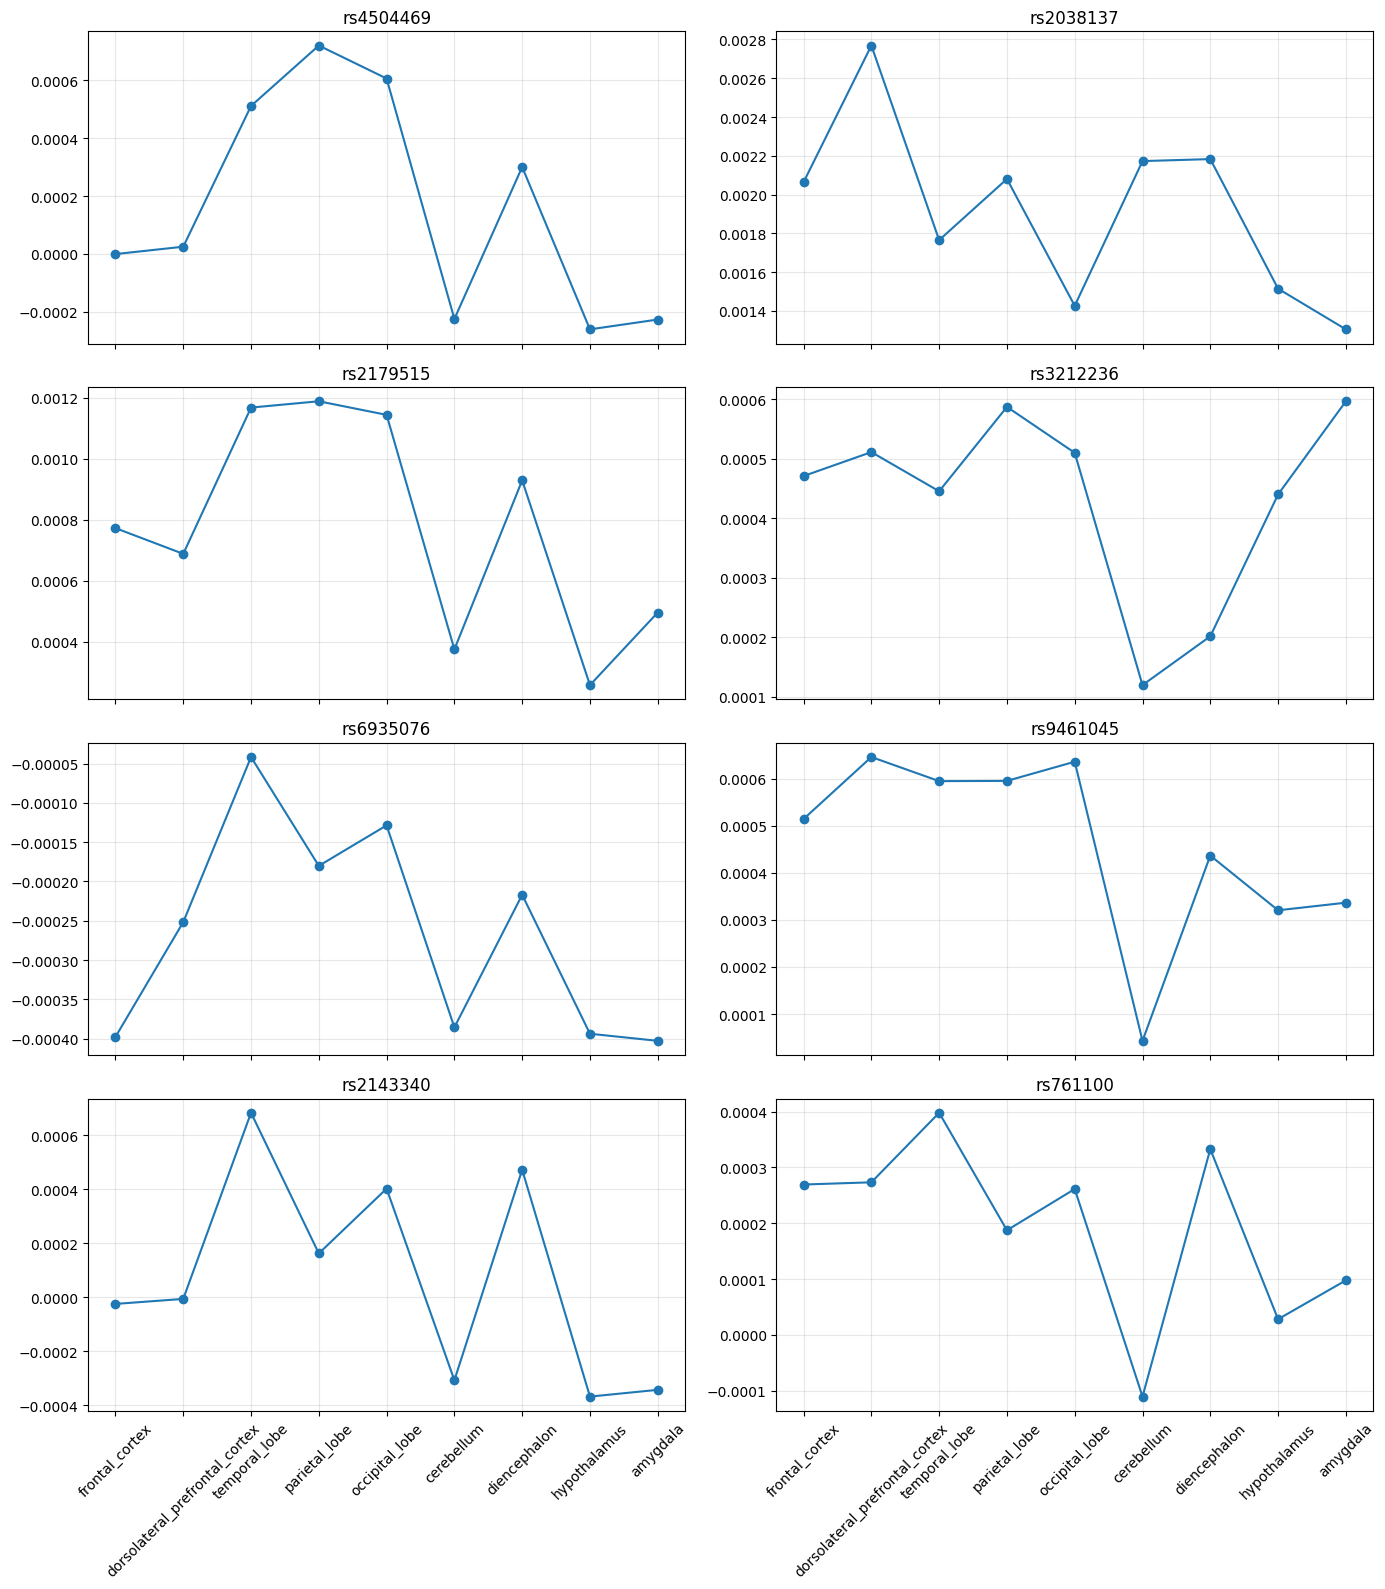

In [ ]:
log_cols = [c for c in kiaa0319_raw.columns if c.startswith("log_fold_change")]
x_labels = [c.replace("log_fold_change_", "") for c in log_cols]

sub = kiaa0319_raw[kiaa0319_raw["snp (pathogenic by dpSNP)"].notna()].copy()

n = len(sub)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharex=True)
axes = axes.flatten()

for ax, (_, row) in zip(axes, sub.iterrows()):
    ax.plot(x_labels, row[log_cols].values, marker="o")
    ax.set_title(str(row["snp (pathogenic by dpSNP)"]))
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=45)

for ax in axes[len(sub):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("all_graphs_kiaa0319.png", dpi=300, bbox_inches="tight")
plt.show()

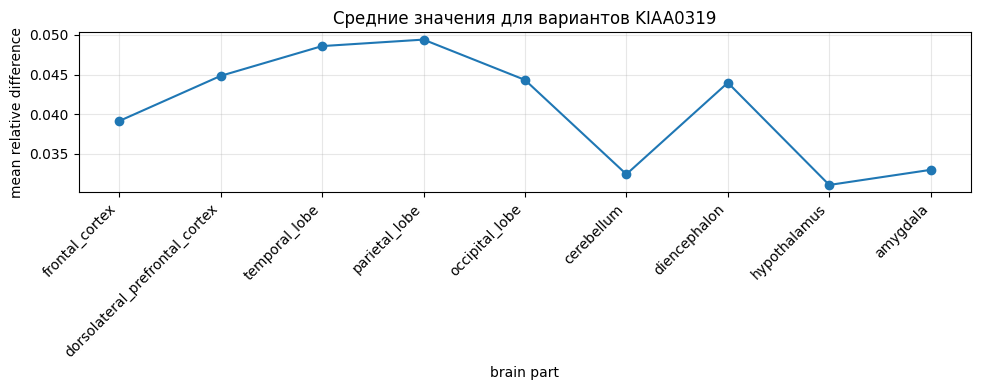

In [ ]:
log_cols = [c for c in kiaa0319_raw.columns if c.startswith("rel_diff")]
x_labels = [c.replace("rel_diff_", "") for c in log_cols]

mean_values = kiaa0319_raw[log_cols].abs().mean(axis=0)

plt.figure(figsize=(10, 4))
plt.plot(x_labels, mean_values.values, marker="o")
plt.xticks(rotation=45, ha="right")
plt.xlabel("brain part")
plt.ylabel("mean relative difference")
plt.title("Средние значения для вариантов KIAA0319")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("mean_kiaa0319.png", dpi=300, bbox_inches="tight")
plt.show()

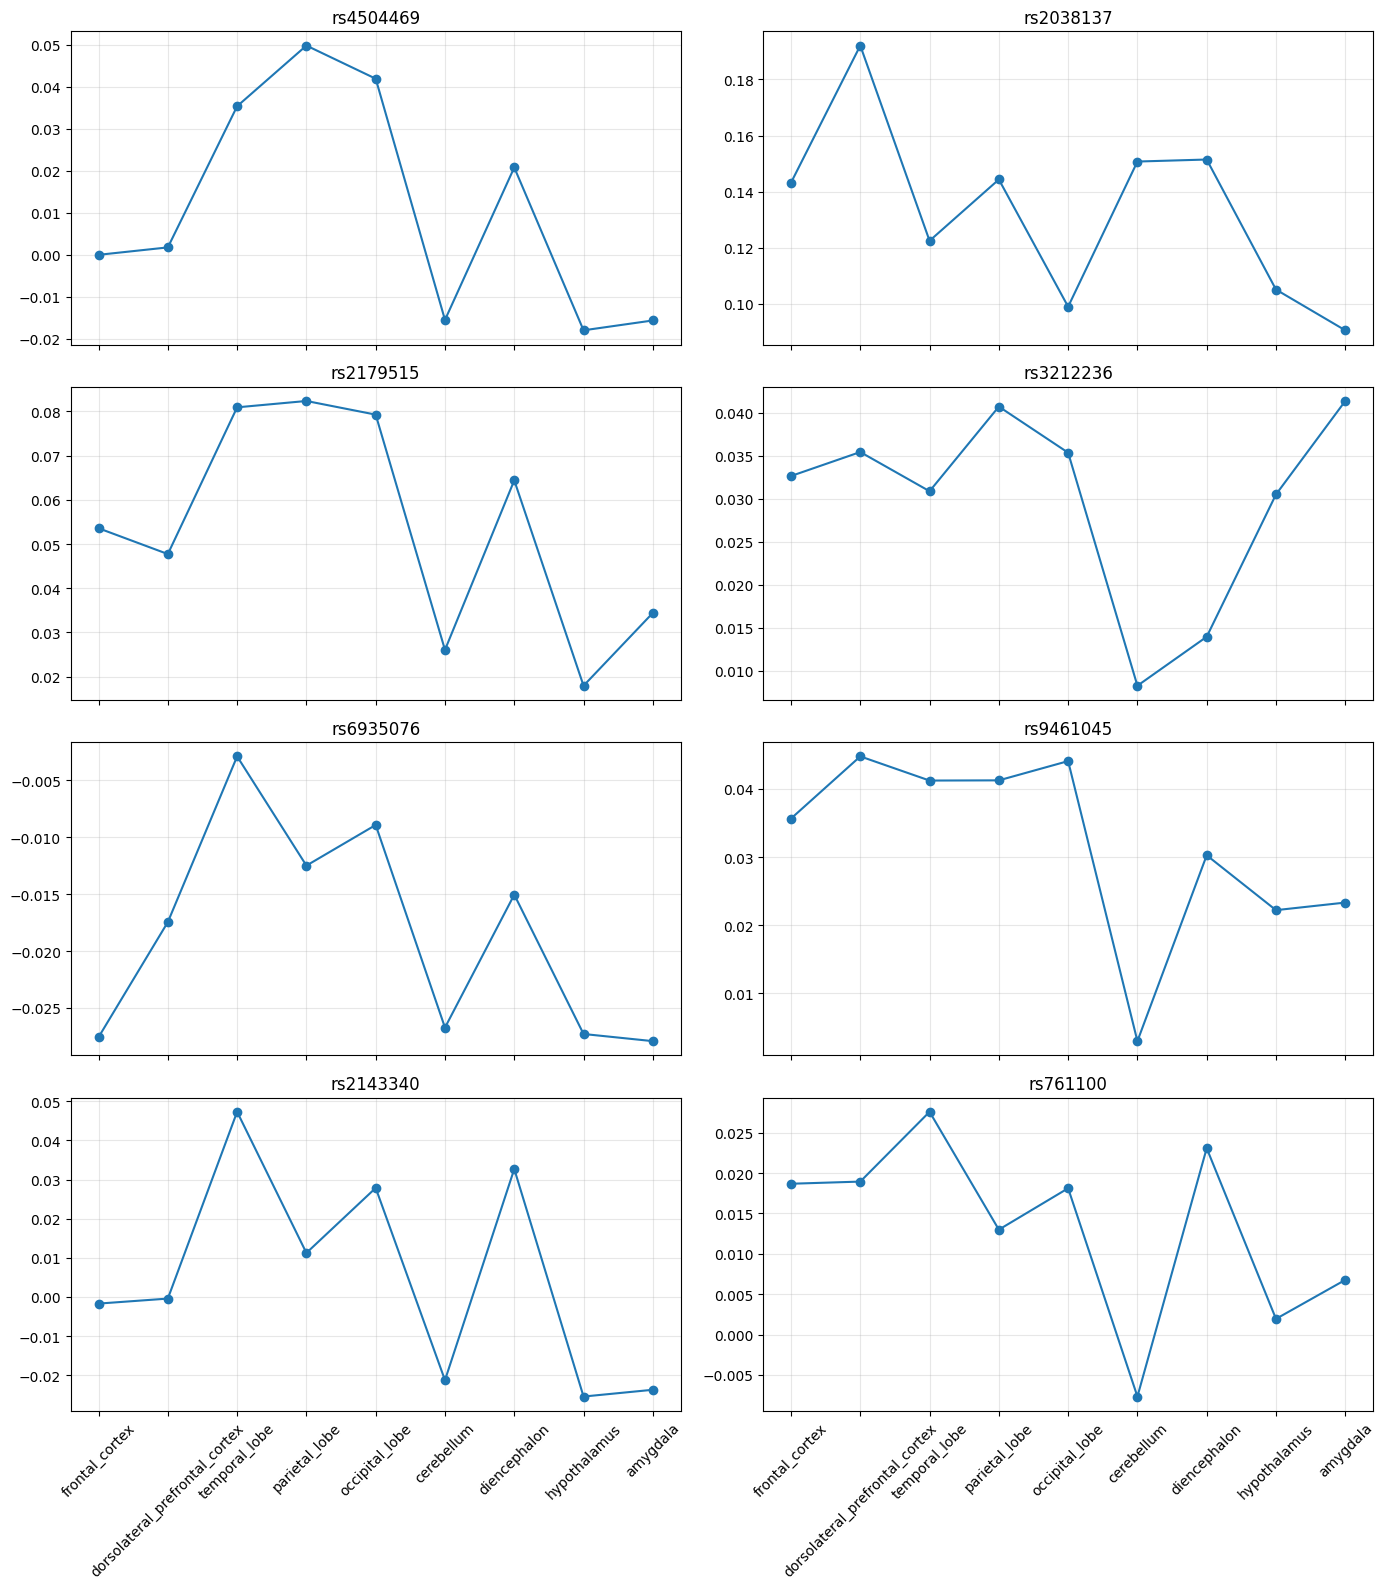

In [ ]:
import math

log_cols = [c for c in kiaa0319_raw.columns if c.startswith("rel_diff")]
x_labels = [c.replace("rel_diff_", "") for c in log_cols]

sub = kiaa0319_raw[kiaa0319_raw["snp (pathogenic by dpSNP)"].notna()].copy()

n = len(sub)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharex=True)
axes = axes.flatten()

for ax, (_, row) in zip(axes, sub.iterrows()):
    ax.plot(x_labels, row[log_cols].values, marker="o")
    ax.set_title(str(row["snp (pathogenic by dpSNP)"]))
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=45)

for ax in axes[len(sub):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("diffs_kiaa0319.png", dpi=300, bbox_inches="tight")
plt.show()

####Отдельно графики для FOXP2

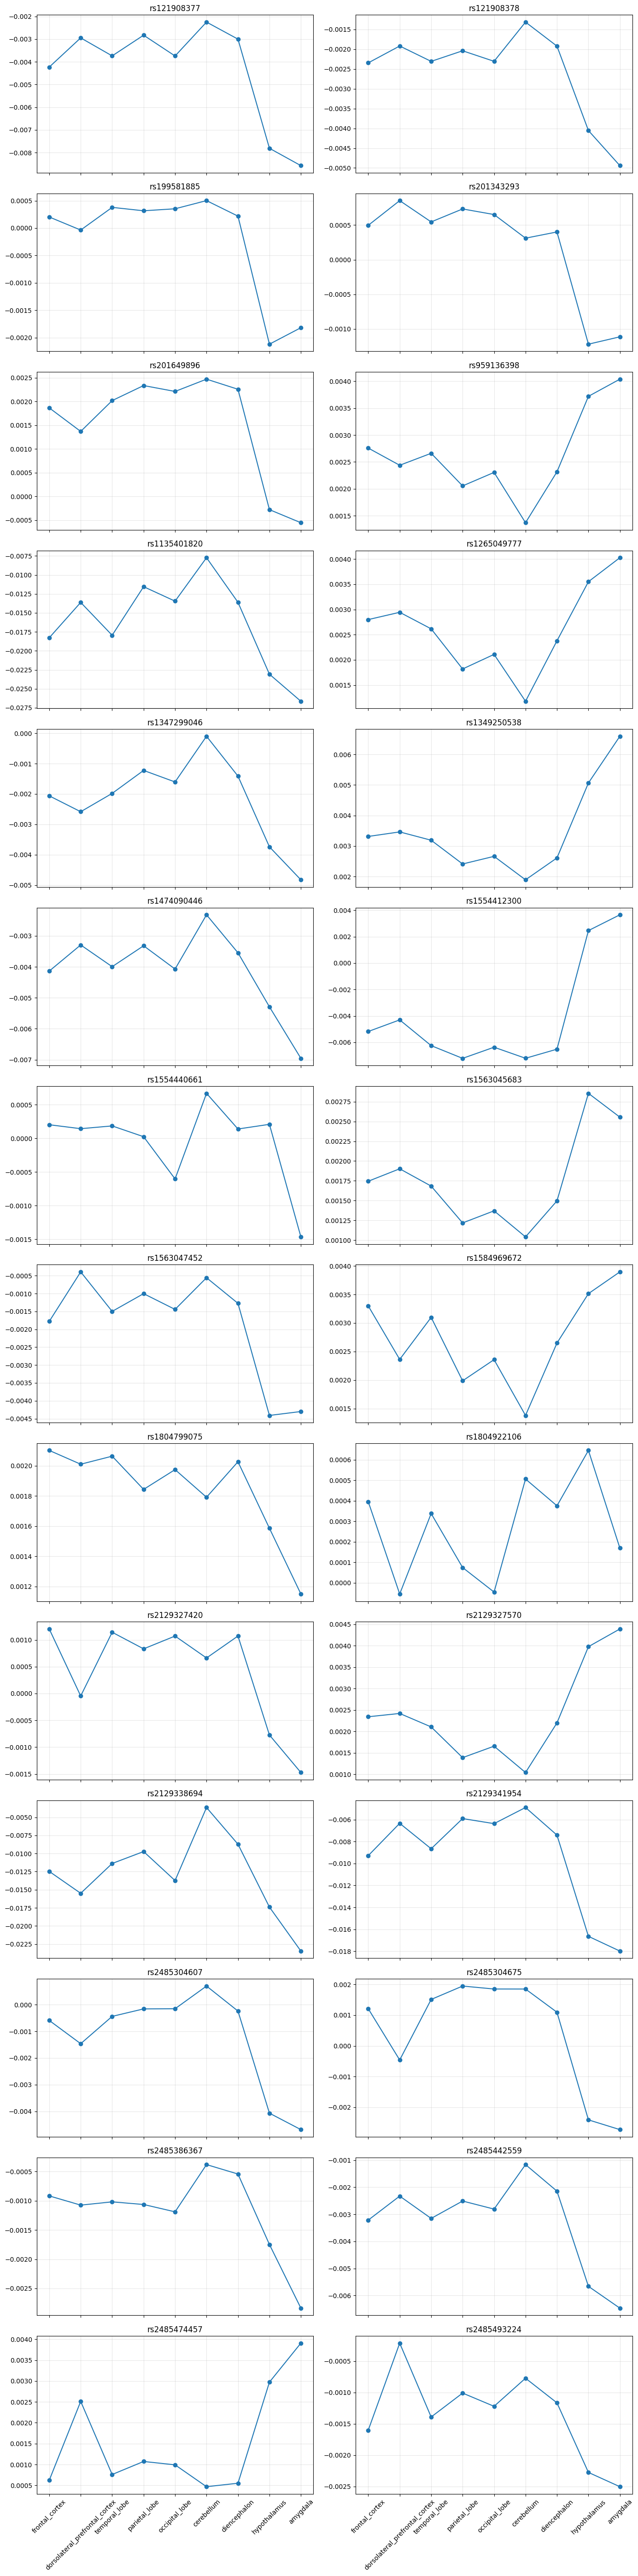

In [ ]:
log_cols = [c for c in foxp2_raw.columns if c.startswith("log_fold_change")]
x_labels = [c.replace("log_fold_change_", "") for c in log_cols]

sub = foxp2_raw[foxp2_raw["snp (pathogenic by dpSNP)"].notna()].copy()

n = len(sub)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharex=True)
axes = axes.flatten()

for ax, (_, row) in zip(axes, sub.iterrows()):
    ax.plot(x_labels, row[log_cols].values, marker="o")
    ax.set_title(str(row["snp (pathogenic by dpSNP)"]))
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=45)

for ax in axes[len(sub):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("all_graphs_foxp2.png", dpi=300, bbox_inches="tight")
plt.show()

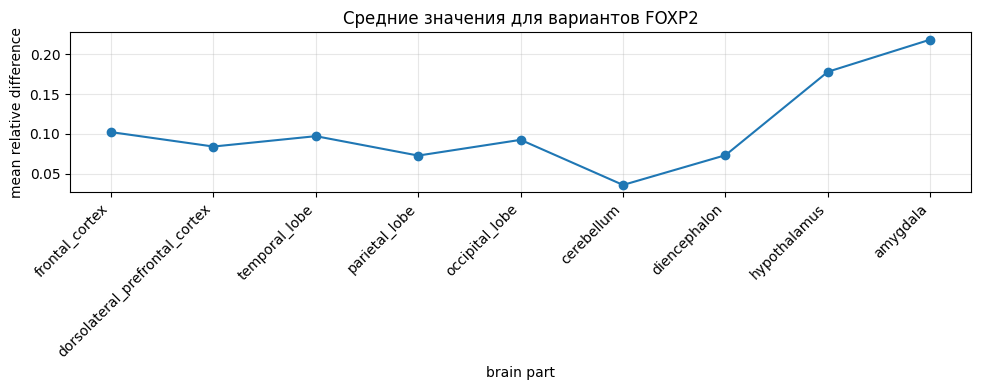

In [ ]:
log_cols = [c for c in foxp2_raw.columns if c.startswith("rel_diff")]
x_labels = [c.replace("rel_diff_", "") for c in log_cols]

mean_values = foxp2_raw[log_cols].mean(axis=0)

plt.figure(figsize=(10, 4))
plt.plot(x_labels, mean_values.abs().values, marker="o")
plt.xticks(rotation=45, ha="right")
plt.xlabel("brain part")
plt.ylabel("mean relative difference")
plt.title("Средние значения для вариантов FOXP2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("mean_graph_foxp2.png", dpi=300, bbox_inches="tight")
plt.show()

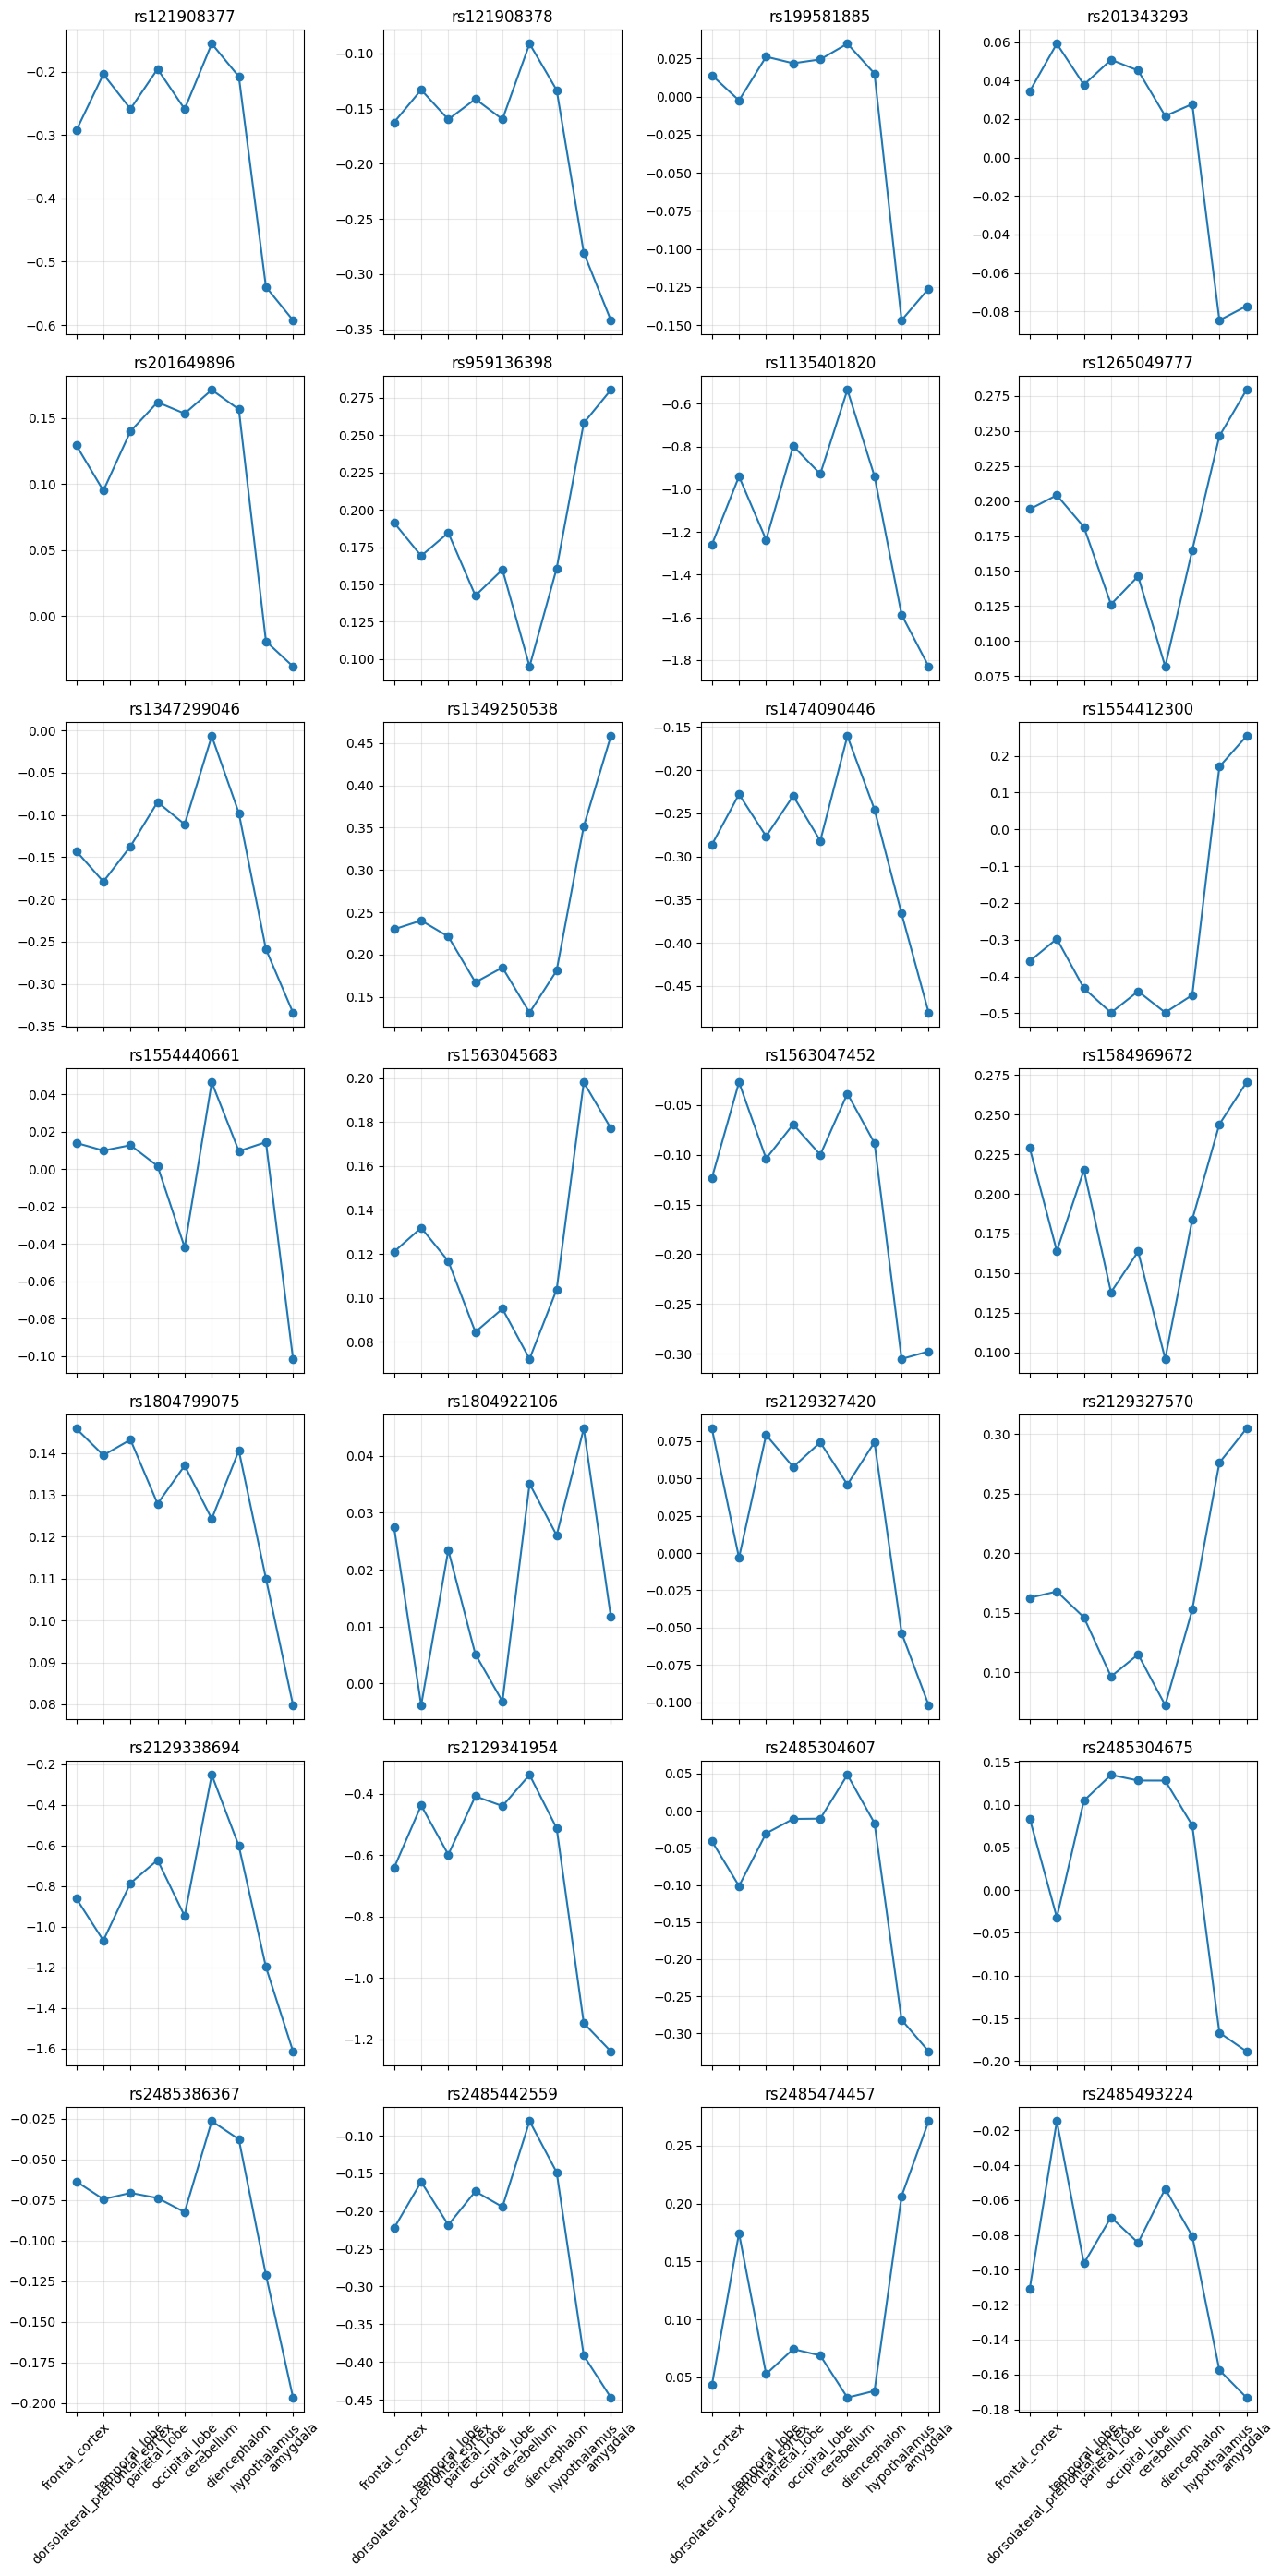

In [ ]:
log_cols = [c for c in foxp2_raw.columns if c.startswith("rel_diff")]
x_labels = [c.replace("rel_diff_", "") for c in log_cols]

sub = foxp2_raw[foxp2_raw["snp (pathogenic by dpSNP)"].notna()].copy()

n = len(sub)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharex=True)
axes = axes.flatten()

for ax, (_, row) in zip(axes, sub.iterrows()):
    ax.plot(x_labels, row[log_cols].values, marker="o")
    ax.set_title(str(row["snp (pathogenic by dpSNP)"]))
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=45)

for ax in axes[len(sub):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("diffs_foxp2.png", dpi=300, bbox_inches="tight")
plt.show()

####Графики для всех снипов: dyx

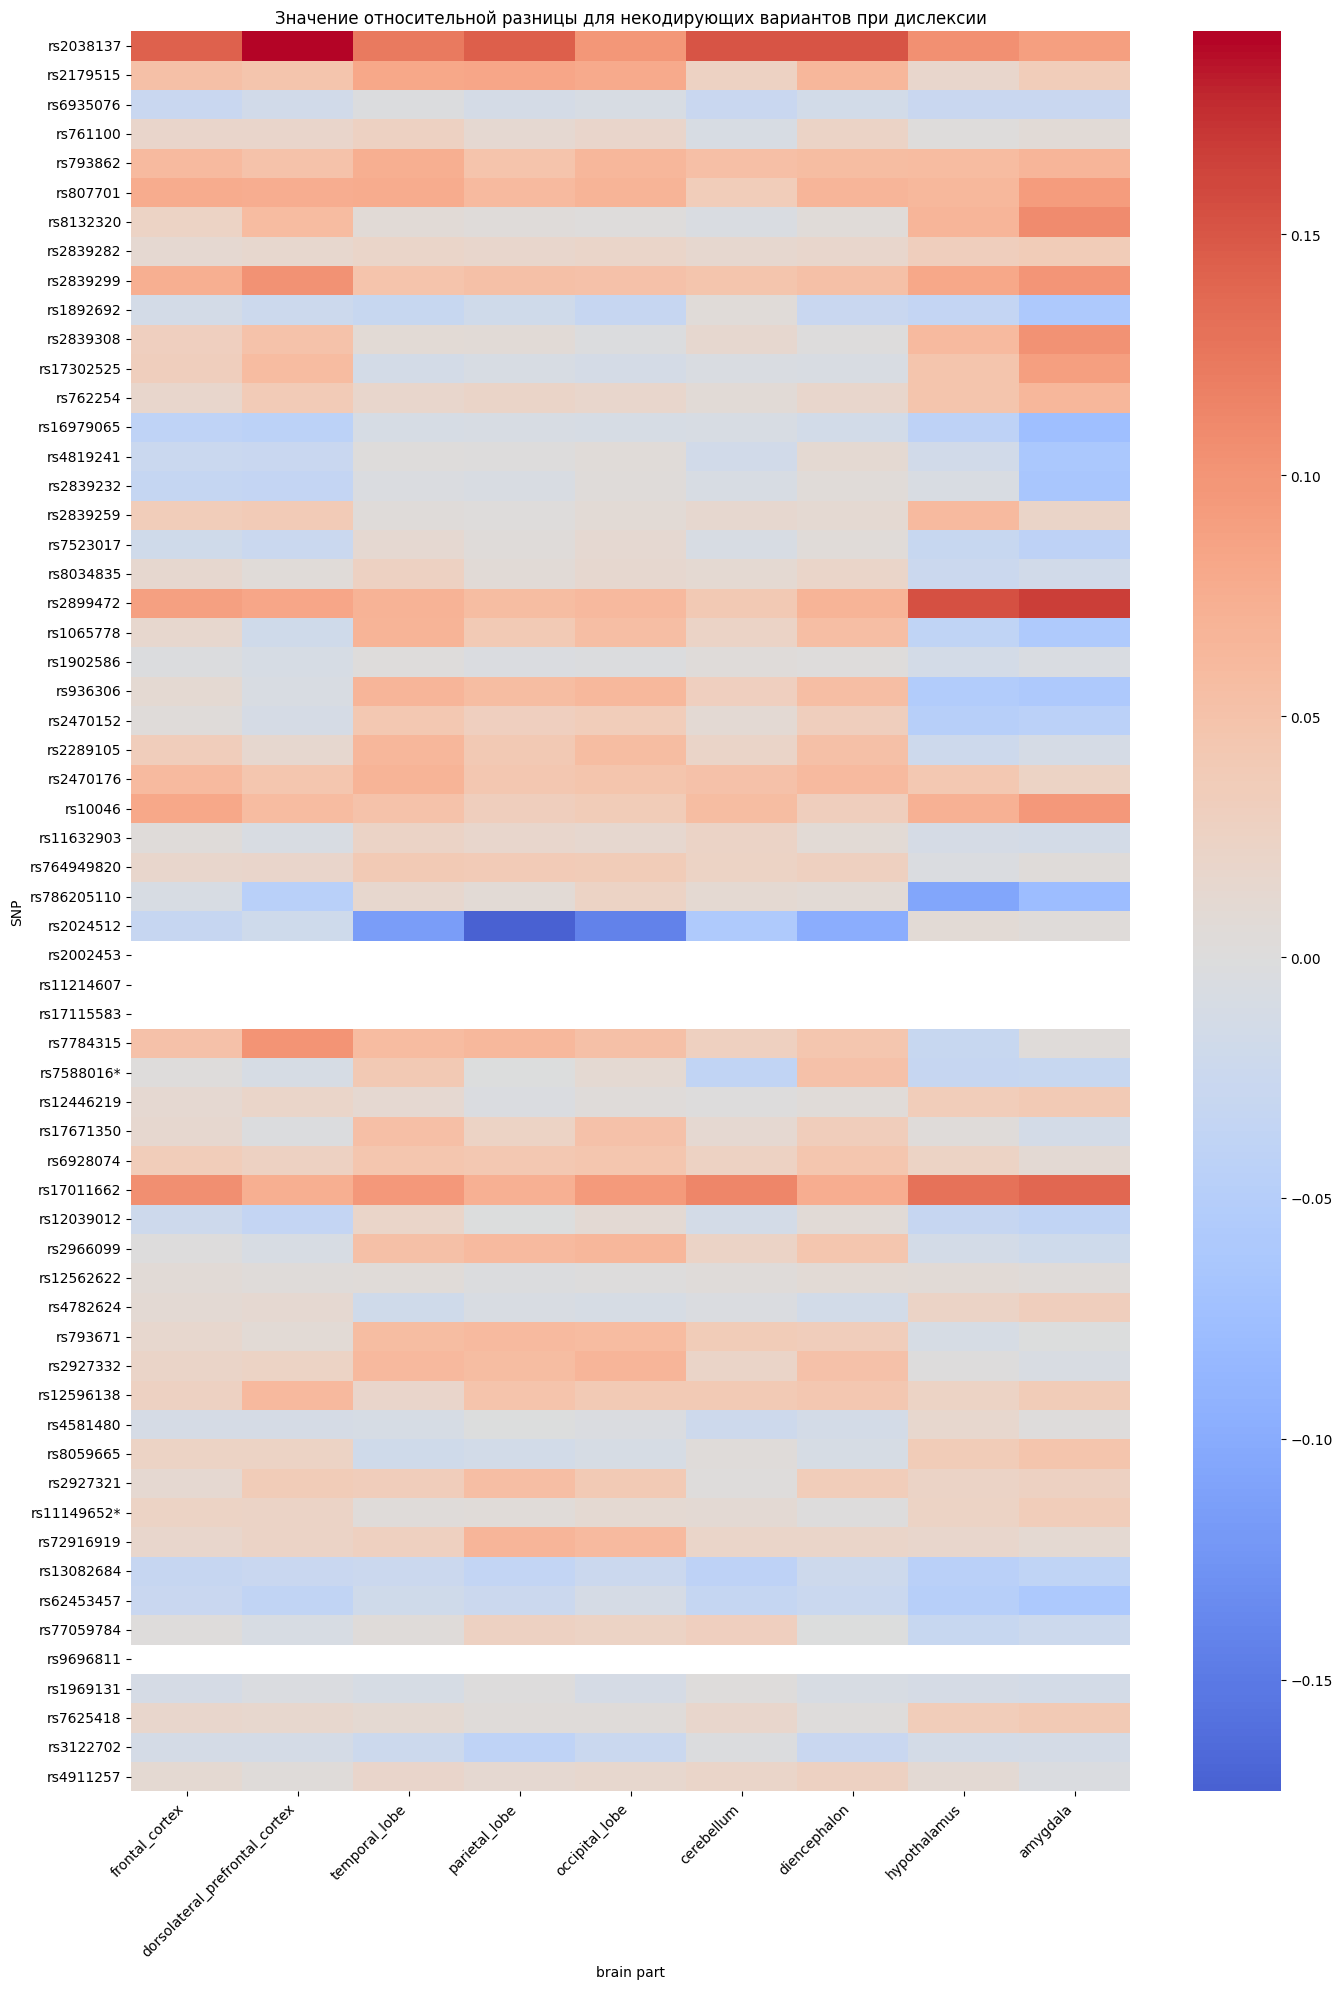

In [ ]:
log_cols = [c for c in dyx_raw.columns if c.startswith("rel_diff")]

plot_dyx = dyx_raw[dyx_raw["snp (pathogenic by dpSNP)"].notna()].copy()
plot_dyx = plot_dyx.set_index("snp (pathogenic by dpSNP)")

heat_data = plot_dyx[log_cols]

x_labels = [c.replace("rel_diff_", "") for c in log_cols]

plt.figure(figsize=(14, 20))
sns.heatmap(
    heat_data,
    cmap="coolwarm",
    center=0,
    xticklabels=x_labels,
    yticklabels=True
)
plt.xlabel("brain part")
plt.ylabel("SNP")
plt.title("Значение относительной разницы для некодирующих вариантов при дислексии")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("dyx_snps.png", dpi=300, bbox_inches="tight")
plt.show()

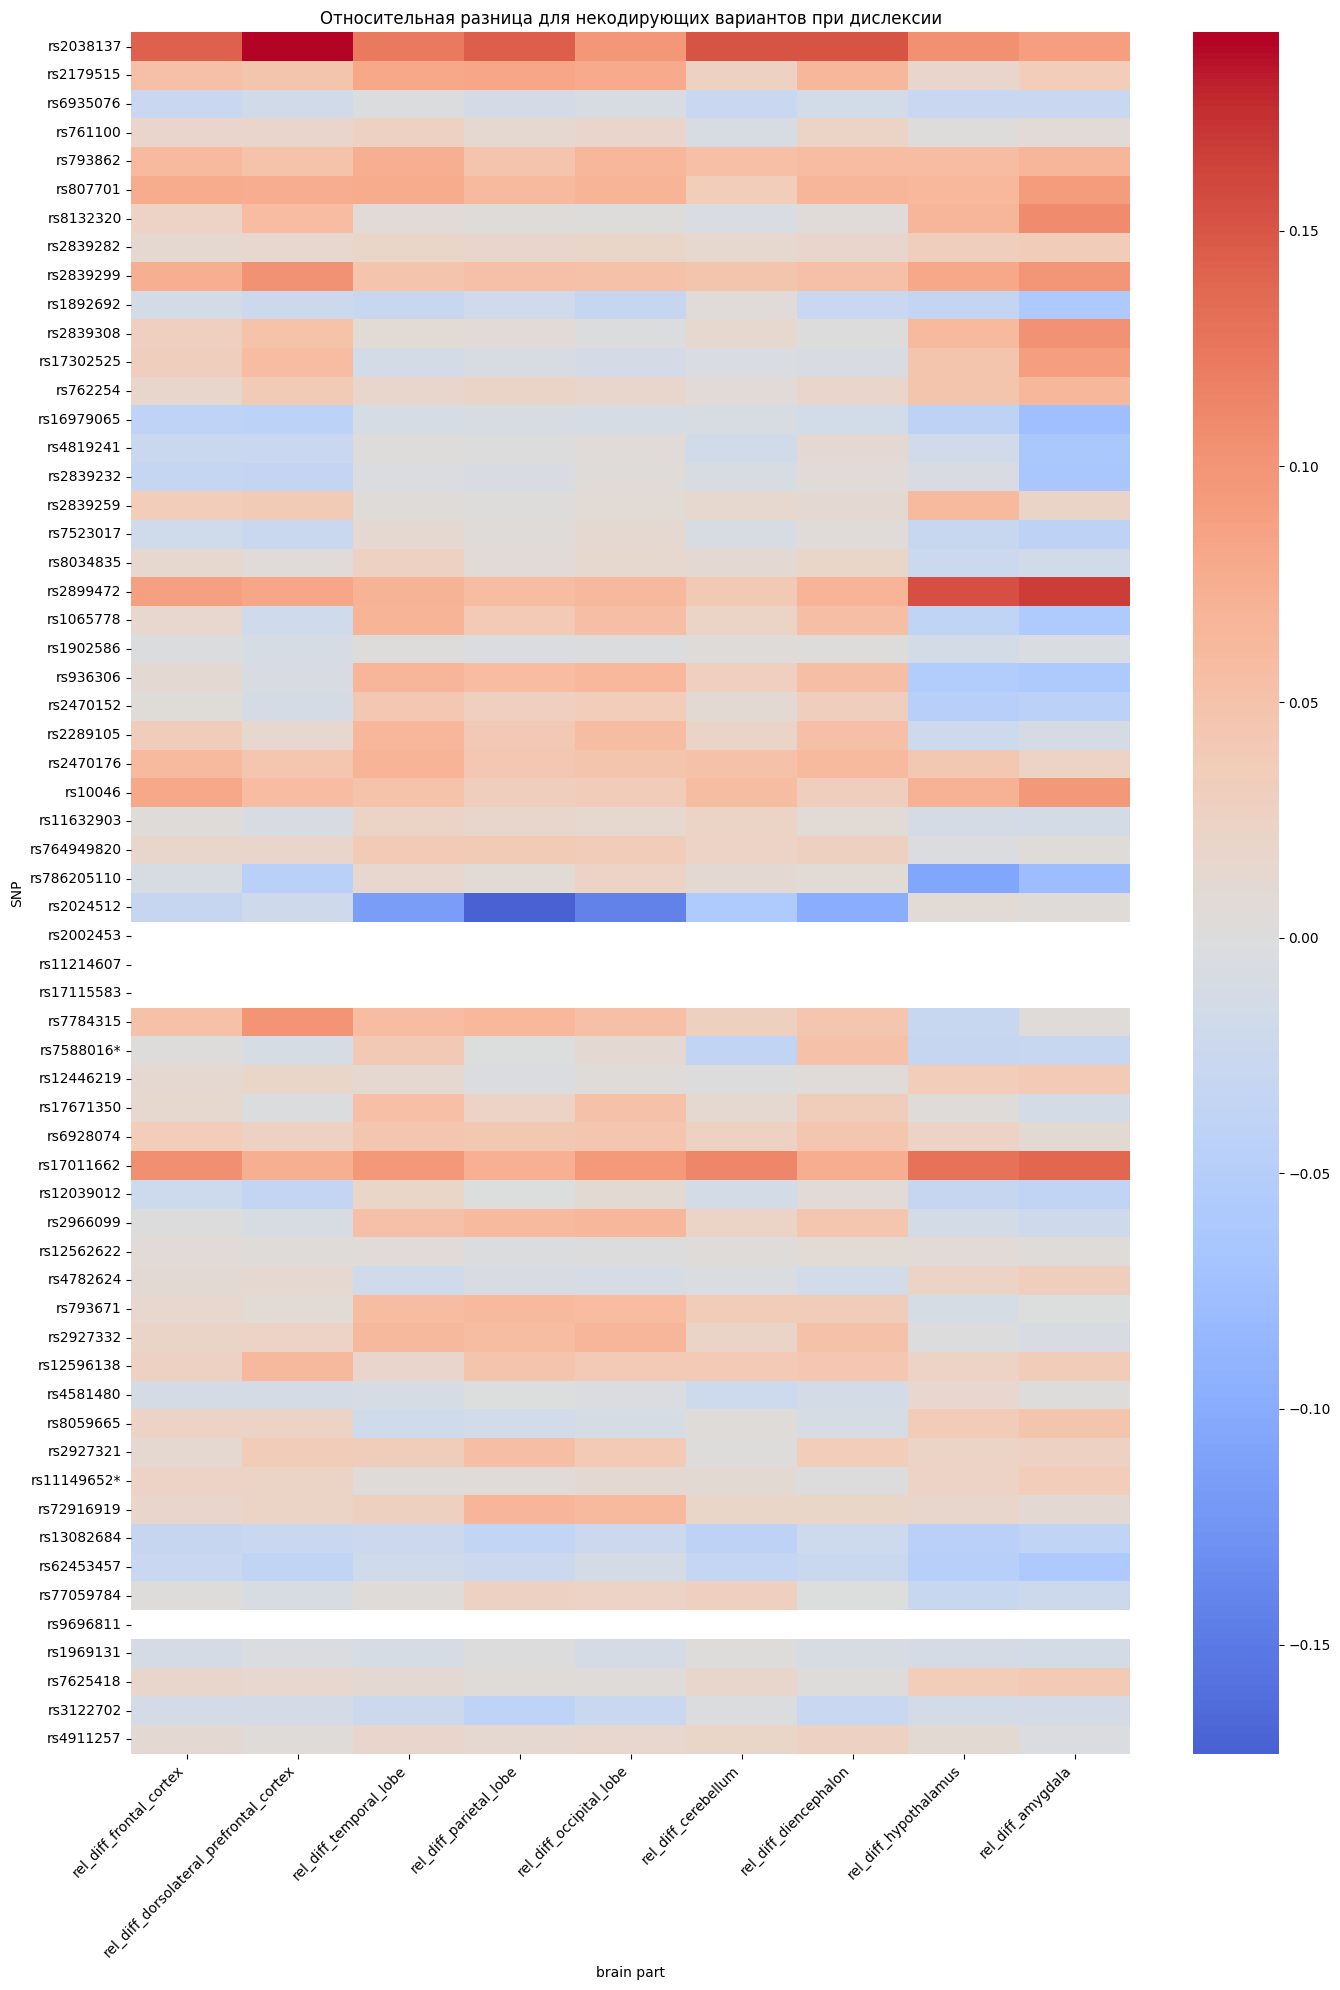

In [ ]:
#он такой же, его можно не убирать

log_cols = [c for c in dyx_raw.columns if c.startswith("rel_diff")]

plot_dyx = dyx_raw[dyx_raw["snp (pathogenic by dpSNP)"].notna()].copy()
plot_dyx = plot_dyx.set_index("snp (pathogenic by dpSNP)")

heat_data = plot_dyx[log_cols]

x_labels = [c.replace("log_fold_change_", "") for c in log_cols]

plt.figure(figsize=(14, 20))
sns.heatmap(
    heat_data,
    cmap="coolwarm",
    center=0,
    xticklabels=x_labels,
    yticklabels=True
)
plt.xlabel("brain part")
plt.ylabel("SNP")
plt.title("Относительная разница для некодирующих вариантов при дислексии")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("dyx_diff.png", dpi=300, bbox_inches="tight")
plt.show()

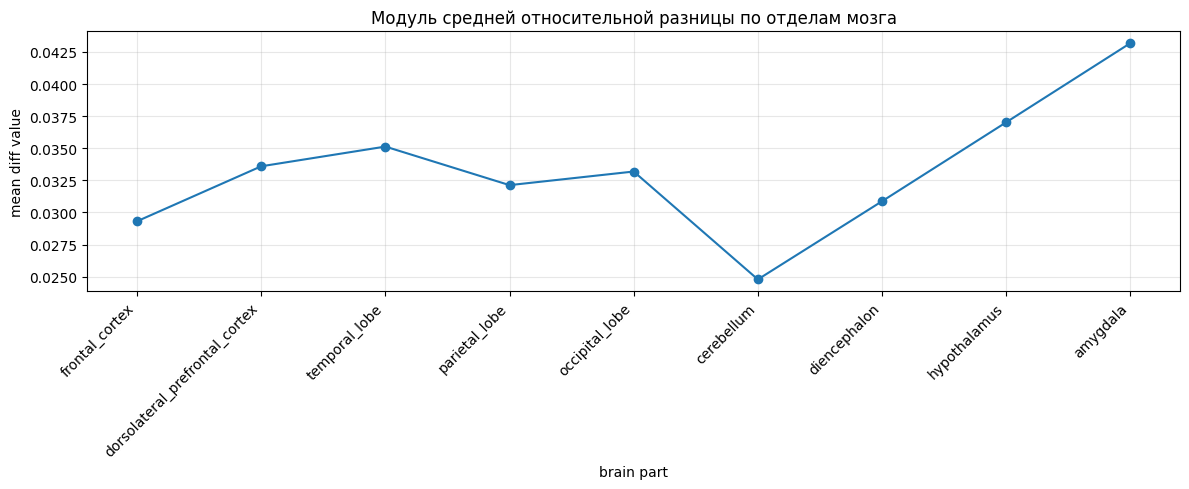

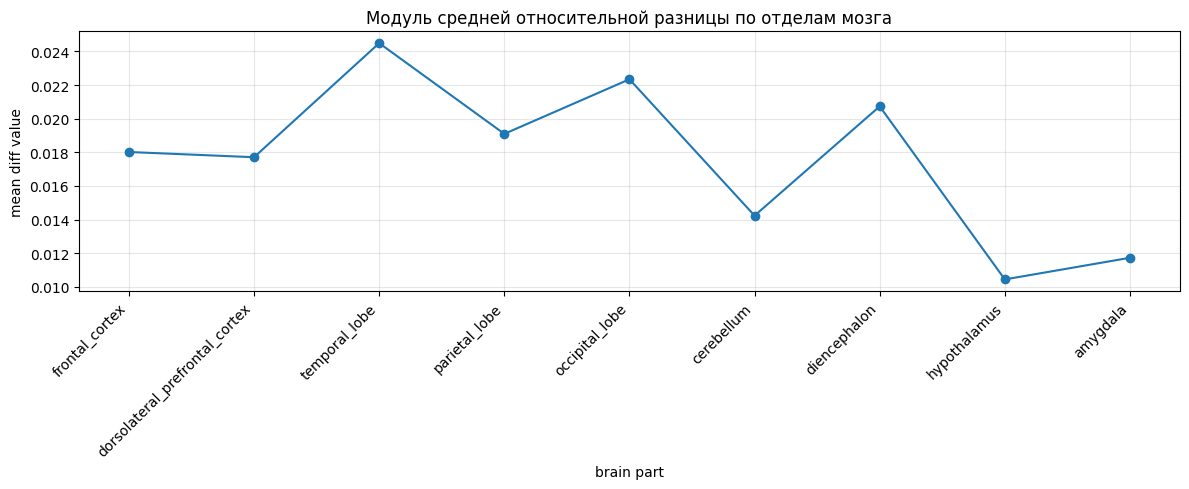

In [ ]:
import matplotlib.pyplot as plt

diff_cols = [c for c in dyx_raw.columns if c.startswith("rel_diff")]
x_labels = [c.replace("rel_diff_", "") for c in log_cols]

sub = dyx_raw[dyx_raw["snp (pathogenic by dpSNP)"].notna()].copy()

mean_values = sub[diff_cols].abs().mean(axis=0)

plt.figure(figsize=(12, 5))
plt.plot(x_labels, mean_values.values, marker="o")
plt.xticks(rotation=45, ha="right")
plt.xlabel("brain part")
plt.ylabel("mean diff value")
plt.title("Модуль средней относительной разницы по отделам мозга")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("mean_diff_dyx.png", dpi=300, bbox_inches="tight")
plt.show()

mean_values = sub[diff_cols].mean(axis=0)

plt.figure(figsize=(12, 5))
plt.plot(x_labels, mean_values.values, marker="o")
plt.xticks(rotation=45, ha="right")
plt.xlabel("brain part")
plt.ylabel("mean diff value")
plt.title("Модуль средней относительной разницы по отделам мозга")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("mean_diff_dyx.png", dpi=300, bbox_inches="tight")
plt.show()

####ЗРР

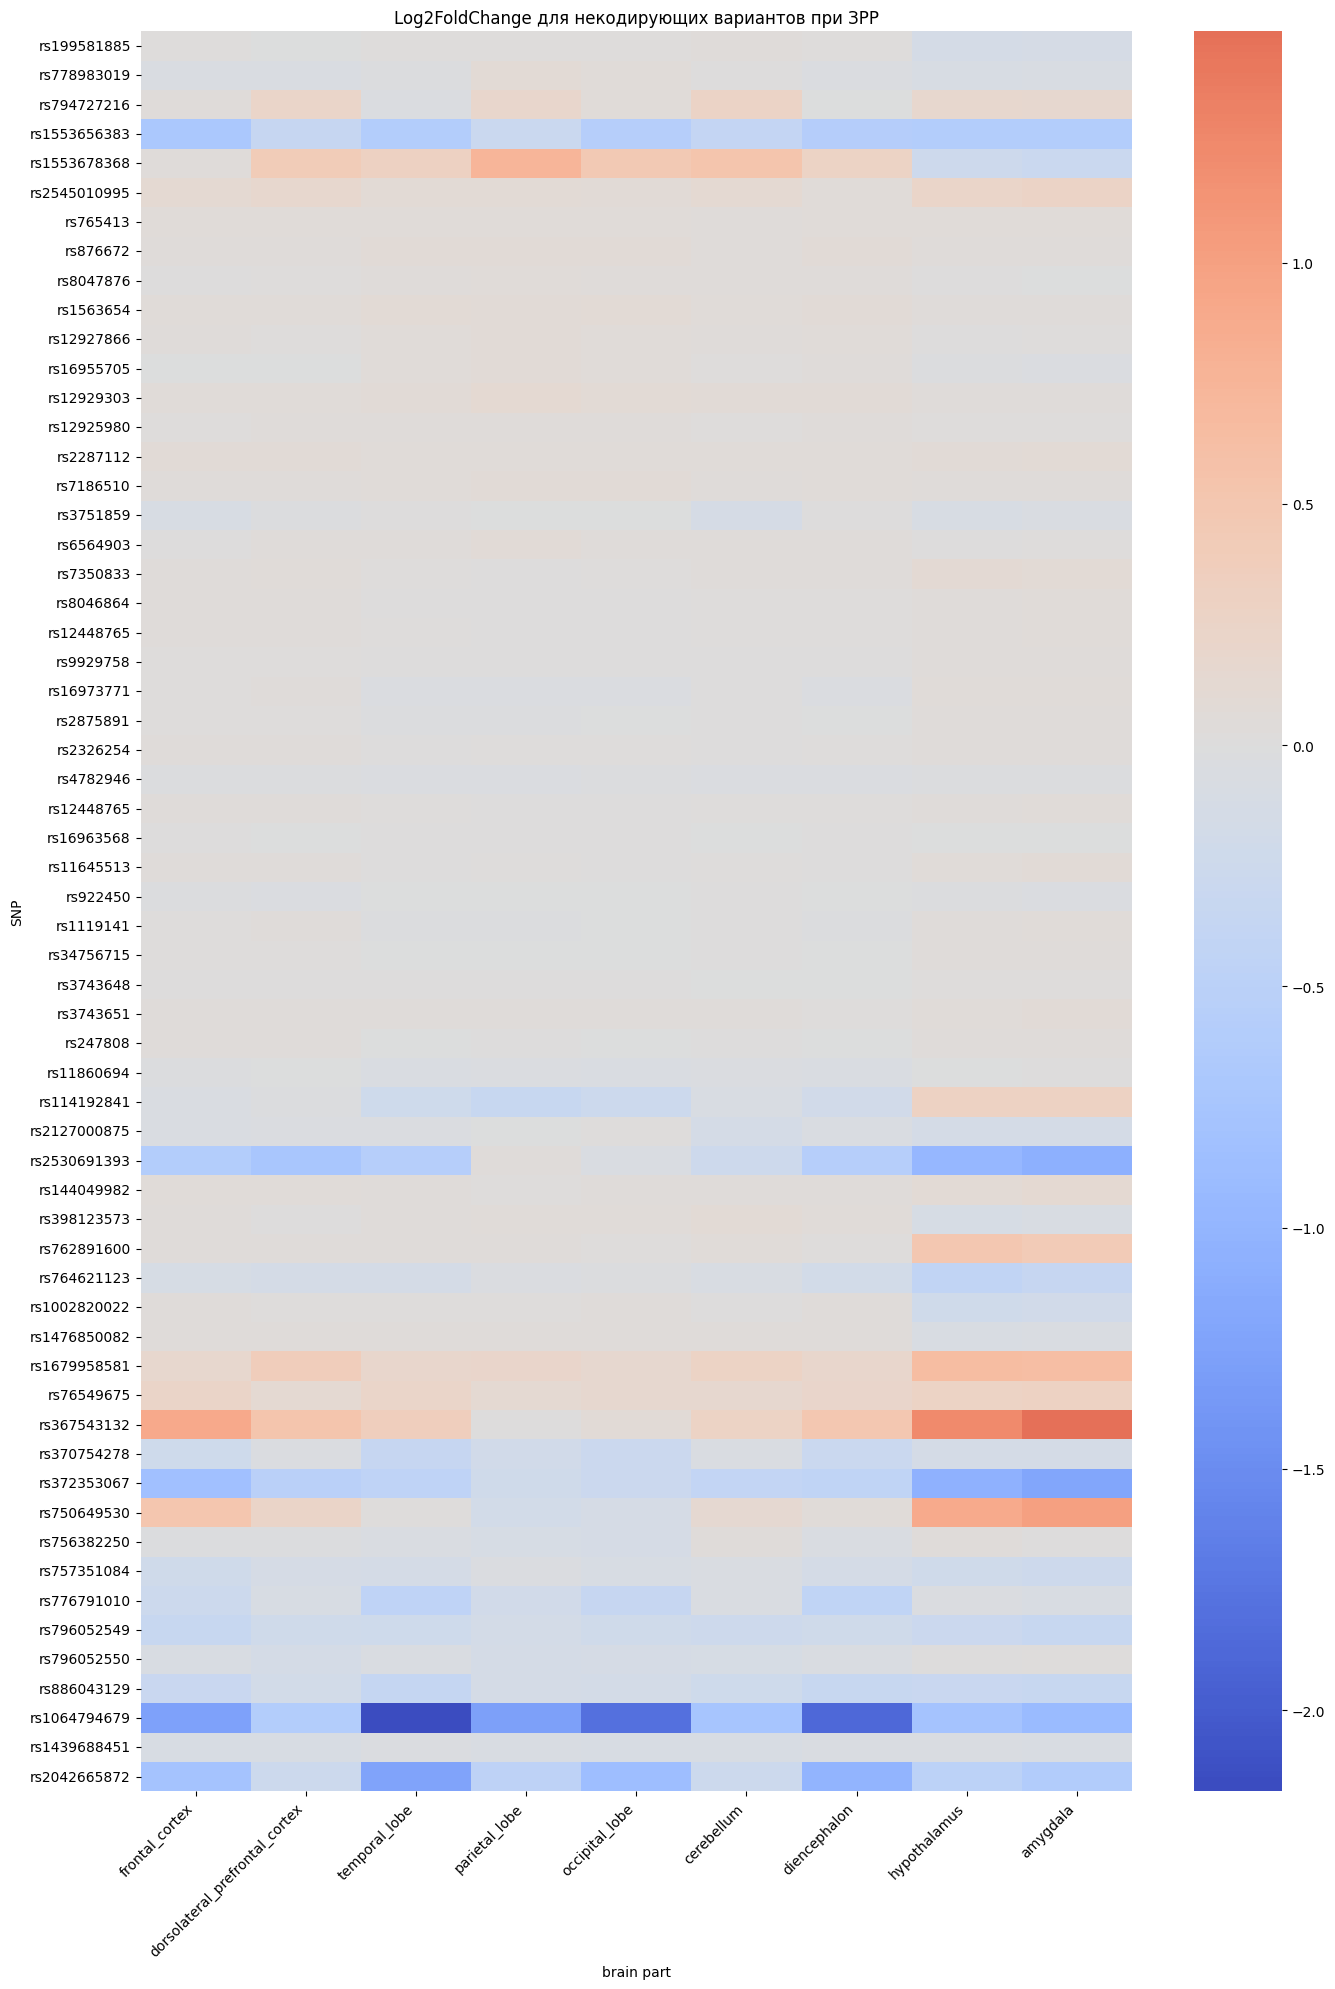

In [ ]:
log_cols = [c for c in dld_raw.columns if c.startswith("rel_diff")]

plot_dld = dld_raw[dyx_raw["snp (pathogenic by dpSNP)"].notna()].copy()
plot_dld = plot_dld.set_index("snp (pathogenic by dpSNP)")

heat_data = plot_dld[log_cols]

x_labels = [c.replace("rel_diff_", "") for c in log_cols]

plt.figure(figsize=(14, 20))
sns.heatmap(
    heat_data,
    cmap="coolwarm",
    center=0,
    xticklabels=x_labels,
    yticklabels=True
)
plt.xlabel("brain part")
plt.ylabel("SNP")
plt.title("Log2FoldChange для некодирующих вариантов при ЗРР")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("dld_snps.png", dpi=300, bbox_inches="tight")
plt.show()

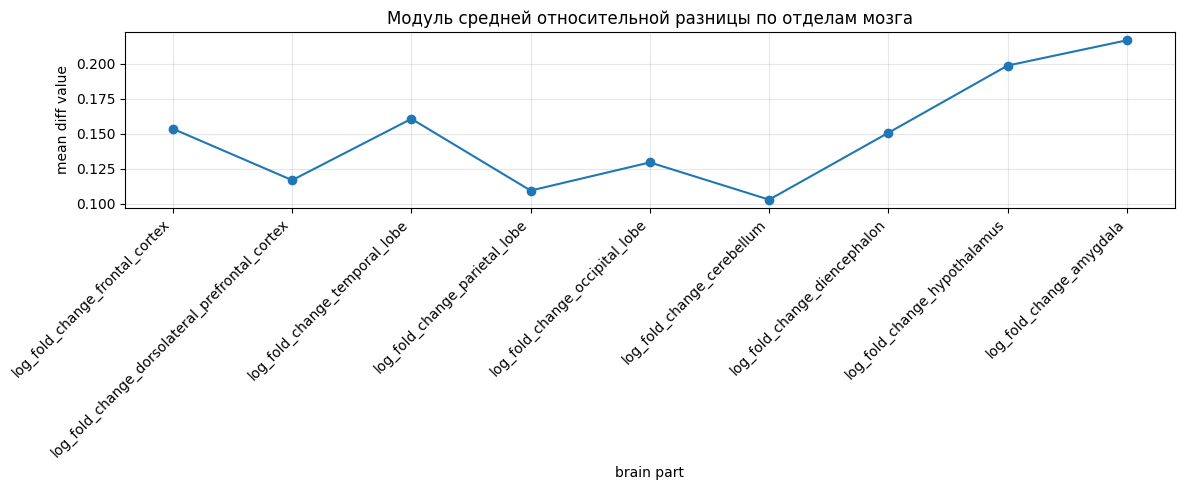

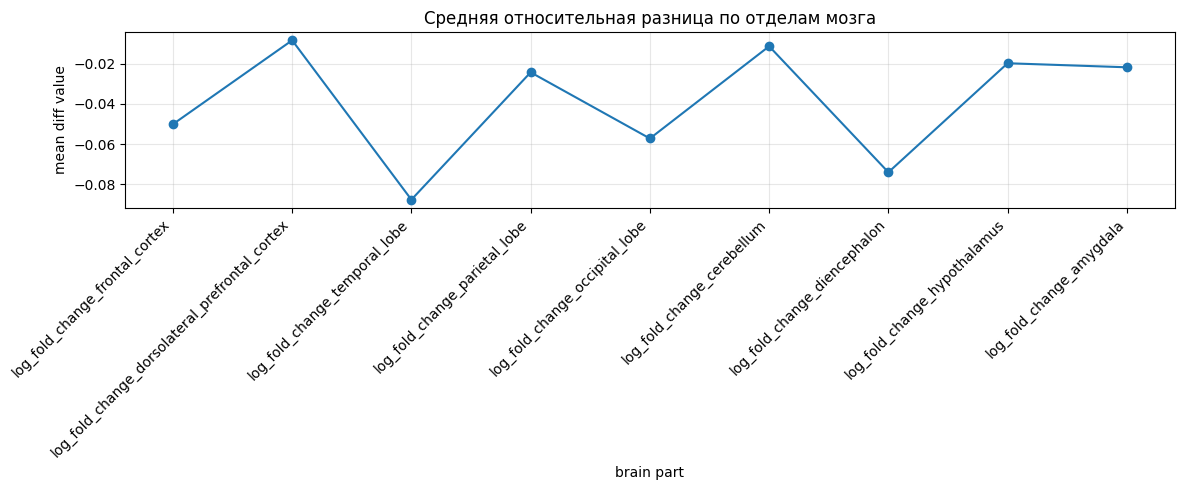

In [ ]:
diff_cols = [c for c in dld_raw.columns if c.startswith("rel_diff")]
x_labels = [c.replace("rel_diff_", "") for c in log_cols]

sub = dld_raw[dld_raw["snp (pathogenic by dpSNP)"].notna()].copy()

mean_values = sub[diff_cols].abs().mean(axis=0)

plt.figure(figsize=(12, 5))
plt.plot(x_labels, mean_values.values, marker="o")
plt.xticks(rotation=45, ha="right")
plt.xlabel("brain part")
plt.ylabel("mean diff value")
plt.title("Модуль средней относительной разницы по отделам мозга")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("mean_diff_dld_abs.png", dpi=300, bbox_inches="tight")
plt.show()

mean_values = sub[diff_cols].mean(axis=0)

plt.figure(figsize=(12, 5))
plt.plot(x_labels, mean_values.values, marker="o")
plt.xticks(rotation=45, ha="right")
plt.xlabel("brain part")
plt.ylabel("mean diff value")
plt.title("Средняя относительная разница по отделам мозга")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("mean_diff_dld.png", dpi=300, bbox_inches="tight")
plt.show()